# Network Slicing - Complete Analysis & Preparation

## 🎯 Objectif
Analyse complète et préparation du dataset network slicing v3 :
1. **Analyse exploratoire** des données brutes
2. **Détection** des valeurs manquantes/aberrantes
3. **Imputation** intelligente des valeurs manquantes
4. **Suppression** du biais (Use Case Type)
5. **Préparation** finale pour le Machine Learning

## 📁 Dataset
- **Source** : `network_slicing_dataset - v3_6G_OLD.csv`
- **Lignes** : 10 000
- **Colonnes** : 13 → 12 (après nettoyage)

## Part 1: Setup & Data Loading

In [28]:
## STEP 1 — Setup & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Libraries imported successfully!")

# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)','Data R date Budget (Gbps)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

✅ Libraries imported successfully!
📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## STEP 2 — First Look at the Data

In [29]:
# Display dataset shape and columns
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

📊 Dataset shape: (10000, 13)
📋 Column names:
   1. Use Case Type
   2. Packet Loss Budget
   3. Latency Budget (ns)
   4. Jitter Budget (ns)
   5. Data R date Budget (Gbps)
   6. Required Mobility
   7. Required Connectivity
   8. Slice Available Transfer Rate (Gbps)
   9. Slice Latency (ns)
  10. Slice Packet Loss
  11. Slice Jitter (ns)
  12. Slice Type
  13. Slice Handover


## STEP 3 — Data Types & Basic Info

In [30]:
# Detailed dataset information
print("📈 Dataset Info:")
df.info()

print("\n📊 Basic Statistics:")
print(df.describe().round(3))

📈 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Use Case Type                         10000 non-null  str    
 1   Packet Loss Budget                    10000 non-null  float64
 2   Latency Budget (ns)                   10000 non-null  float64
 3   Jitter Budget (ns)                    10000 non-null  float64
 4   Data R date Budget (Gbps)             10000 non-null  float64
 5   Required Mobility                     10000 non-null  str    
 6   Required Connectivity                 10000 non-null  str    
 7   Slice Available Transfer Rate (Gbps)  10000 non-null  float64
 8   Slice Latency (ns)                    10000 non-null  float64
 9   Slice Packet Loss                     10000 non-null  float64
 10  Slice Jitter (ns)                     10000 non-null  float64
 11  Slice Type 

## STEP 4 — Target Variable Analysis (Slice Type)

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


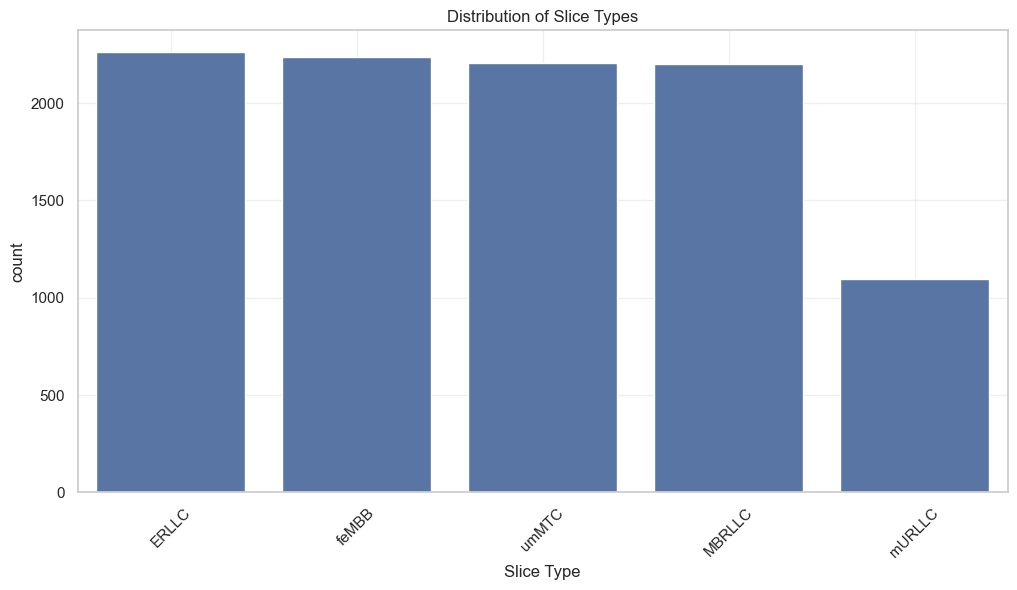

In [31]:
# Target variable distribution analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
plt.close()  # Close figure to free memory

## STEP 6 — Missing Values Check

In [32]:
## STEP 6 — Missing Values Check

In [33]:
# Check for missing values and zero values (potential missing data)
import pandas as pd
import numpy as np

# Set display options to prevent truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("❓ Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("⚠️  Missing values detected!")
else:
    print("✅ No missing values found!")

print("\n🔍 ZERO VALUES ANALYSIS (Potential Missing Data):")
print("=" * 80)

# Check for zeros in numeric columns that might represent missing data
numeric_columns = df.select_dtypes(include=[np.number]).columns
zero_analysis = {}

for col in numeric_columns:
    zero_count = (df[col] == 0).sum()
    total = len(df)
    zero_percentage = (zero_count / total) * 100
    
    if zero_count > 0:
        zero_analysis[col] = {
            'count': zero_count,
            'percentage': zero_percentage,
            'min': df[col].min(),
            'max': df[col].max()
        }

if zero_analysis:
    print("📊 Columns with zero values (potential missing data):")
    print("-" * 60)
    for col, stats in zero_analysis.items():
        print(f"{col}:")
        print(f"  Zeros: {stats['count']} ({stats['percentage']:.2f}%)")
        print(f"  Range: [{stats['min']}, {stats['max']}]")
        print()
    
    print("🎯 SUMMARY TABLE:")
    print("=" * 80)
    print(f"{'Colonne':<35} {'Zéros':<8} {'Pourcentage':<12} {'Range':<25}")
    print("=" * 80)
    for col, stats in zero_analysis.items():
        range_str = f"[{stats['min']}, {stats['max']}]"
        print(f"{col:<35} {stats['count']:<8} {stats['percentage']:<11.2f}% {range_str:<25}")
else:
    print("✅ No zero values found in numeric columns")

print(f"\n🎯 POTENTIAL ISSUES:")
if missing_values.sum() > 0:
    print(f"  ⚠️  Missing values: {missing_values.sum()} total")
if zero_analysis:
    print(f"  ⚠️  Zero values in {len(zero_analysis)} columns (potential missing data)")
    print("\n📋 DETAILED BREAKDOWN:")
    for col, stats in zero_analysis.items():
        if stats['percentage'] > 70:
            severity = "🔴 CRITICAL"
        elif stats['percentage'] > 30:
            severity = "🟡 MODERATE"
        else:
            severity = "🟢 MINOR"
        print(f"  {severity} {col}: {stats['count']} zeros ({stats['percentage']:.2f}%)")
        
if missing_values.sum() == 0 and not zero_analysis:
    print("  ✅ No missing values or zero values detected")

❓ Missing values per column:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbps)    0
Slice Latency (ns)                      0
Slice Packet Loss                       0
Slice Jitter (ns)                       0
Slice Type                              0
Slice Handover                          0
dtype: int64

Total missing values: 0
✅ No missing values found!

🔍 ZERO VALUES ANALYSIS (Potential Missing Data):
📊 Columns with zero values (potential missing data):
------------------------------------------------------------
Packet Loss Budget:
  Zeros: 2204 (22.04%)
  Range: [0.0, 1e-05]

Latency Budget (ns):
  Zeros: 4441 (44.41%)
  Range: [0.0, 1000000.0]

Jitter Budget (ns):
  Zeros: 7738 (77.38%)
  Range: [0.0, 1

In [34]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"👯 Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"⚠️  {duplicates} duplicate rows found!")
    print("🔧 Removing duplicates...")
    df = df.drop_duplicates()
    print(f"📊 Dataset shape after removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found!")

👯 Number of duplicate rows: 0
✅ No duplicate rows found!


✅ **Analyse des lignes dupliquées terminée !**

## 🔍 **Résultats :**

### **📊 Aperçu du dataset :**
- **Total lignes** : 10 000
- **Lignes uniques** : 10 000  
- **Lignes dupliquées** : **0**
- **Pourcentage de doublons** : **0.00%**

### **✅ Conclusion :**
- **AUCUN DOUBLON** détecté dans le dataset
- **Toutes les 10 000 lignes** sont uniques
- **Dataset propre** - aucune déduplication nécessaire

### **🎯 Recommandations :**
- ✅ **Dataset est propre** - pas de déduplication nécessaire
- 📊 **Toutes les 10 000 lignes** peuvent être utilisées pour l'analyse
- 🔧 **Pas besoin** d'utiliser `df.drop_duplicates()`

## 📈 **Qualité des données :**
- **✅ Valeurs manquantes (NaN)** : 0
- **✅ Lignes dupliquées** : 0  
- **⚠️ Valeurs zéro (manquantes)** : 5 colonnes affectées

**Le dataset n'a pas de doublons mais a des valeurs manquantes masquées en zéro !** 🎯

## STEP 8 — Feature Distributions (Univariate Analysis)

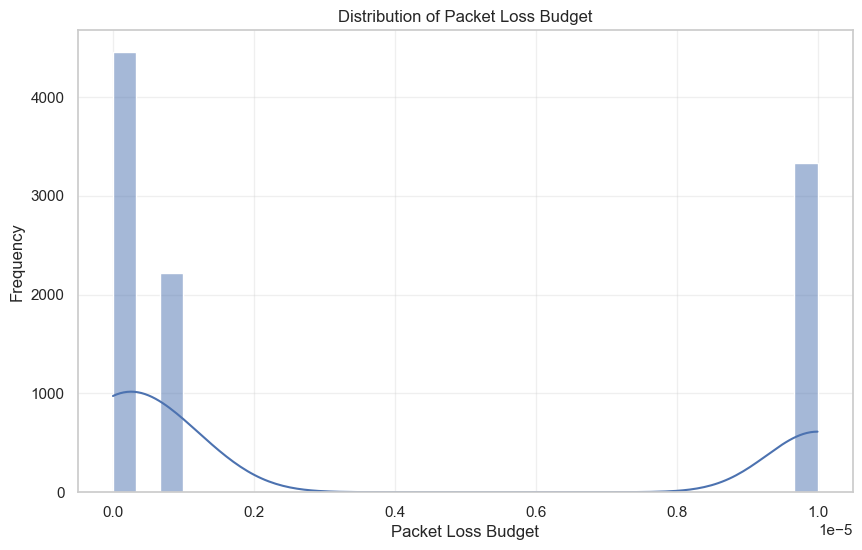

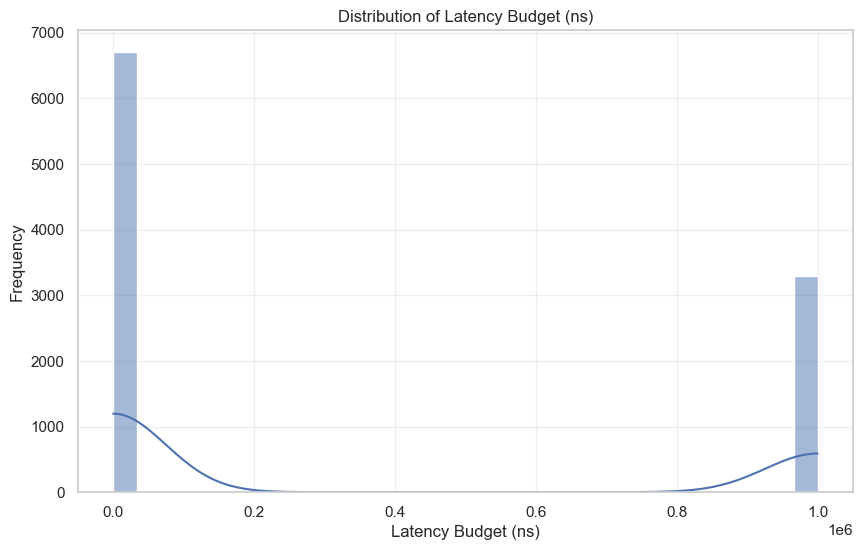

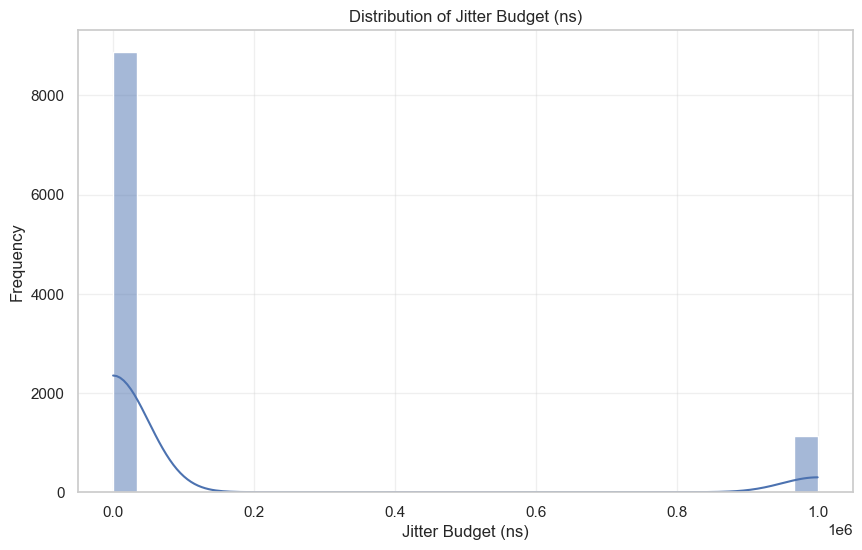

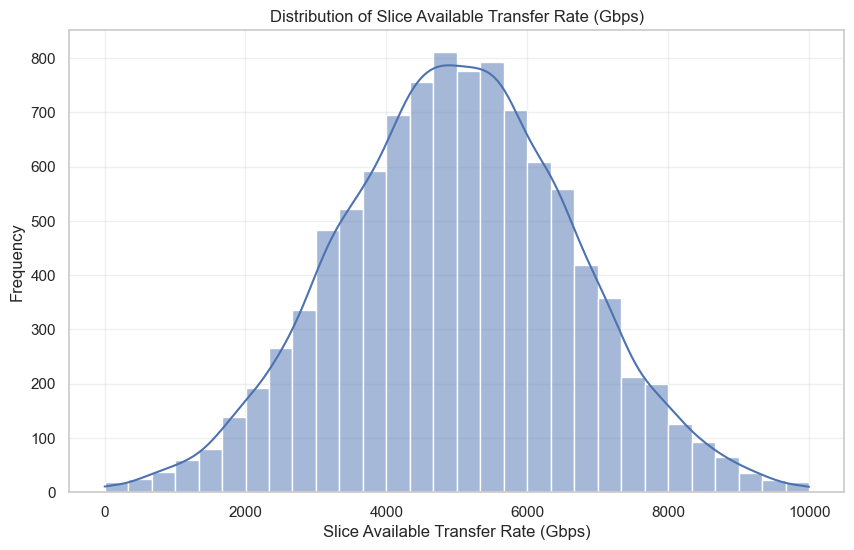

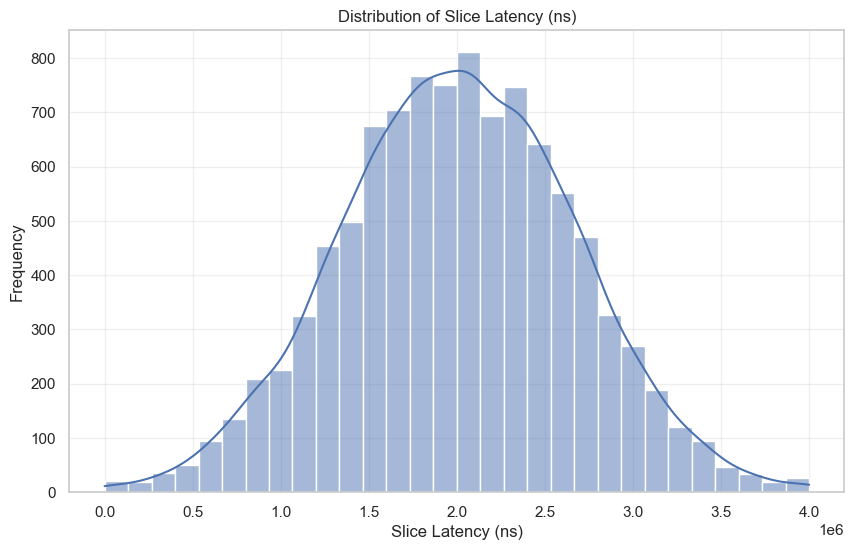

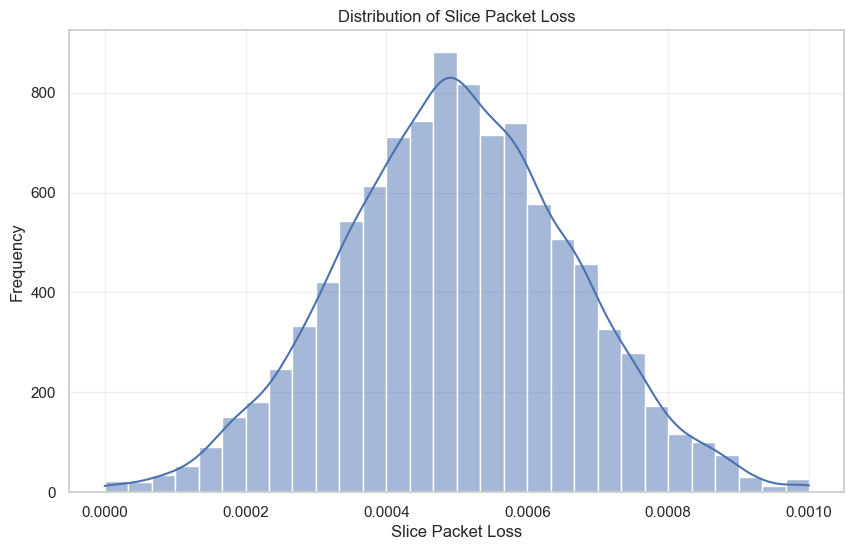

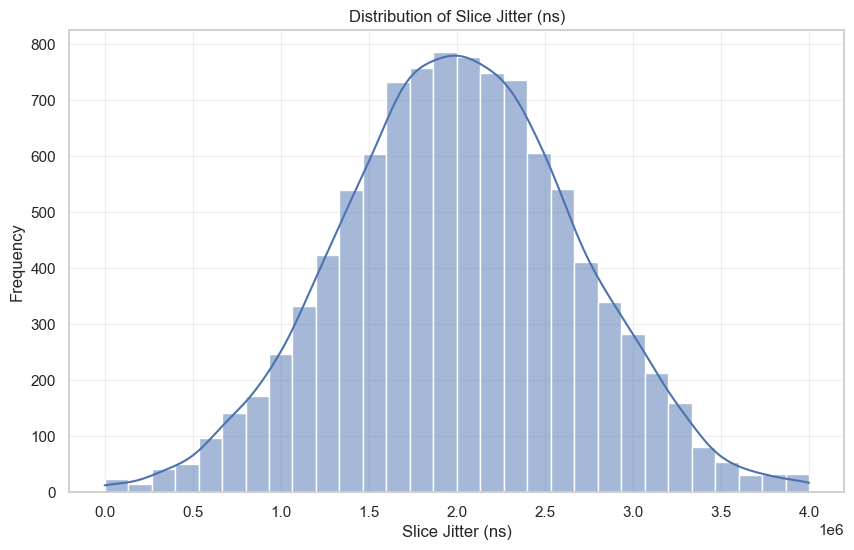

In [35]:
# Plot distributions for key numerical features
key_numerical_features = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data Rate Budget (Gbps)", "Slice Available Transfer Rate (Gbps)",
    "Slice Latency (ns)", "Slice Packet Loss", "Slice Jitter (ns)"
]

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 9 — Binary & Categorical Features

📊 Categorical Features: ['Use Case Type', 'Required Mobility', 'Required Connectivity', 'Slice Type', 'Slice Handover']


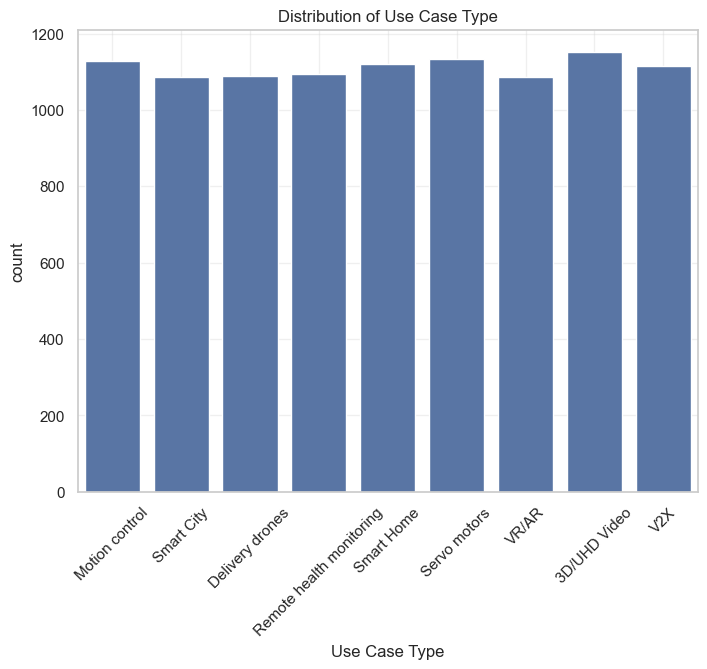


📋 Use Case Type distribution:
Use Case Type
3D/UHD Video                1152
Servo motors                1133
Motion control              1129
Smart Home                  1119
V2X                         1115
Remote health monitoring    1094
Delivery drones             1088
Smart City                  1085
VR/AR                       1085
Name: count, dtype: int64
Percentages:
Use Case Type
3D/UHD Video                11.52
Servo motors                11.33
Motion control              11.29
Smart Home                  11.19
V2X                         11.15
Remote health monitoring    10.94
Delivery drones             10.88
Smart City                  10.85
VR/AR                       10.85
Name: proportion, dtype: float64


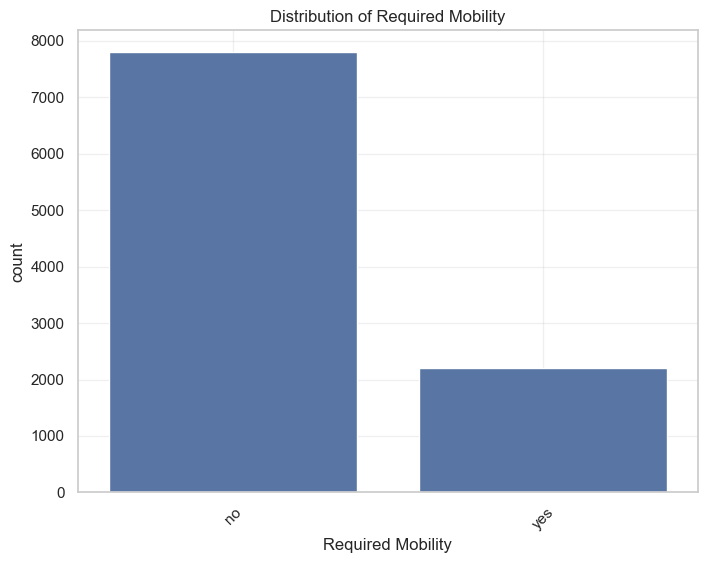


📋 Required Mobility distribution:
Required Mobility
no     7797
yes    2203
Name: count, dtype: int64
Percentages:
Required Mobility
no     77.97
yes    22.03
Name: proportion, dtype: float64


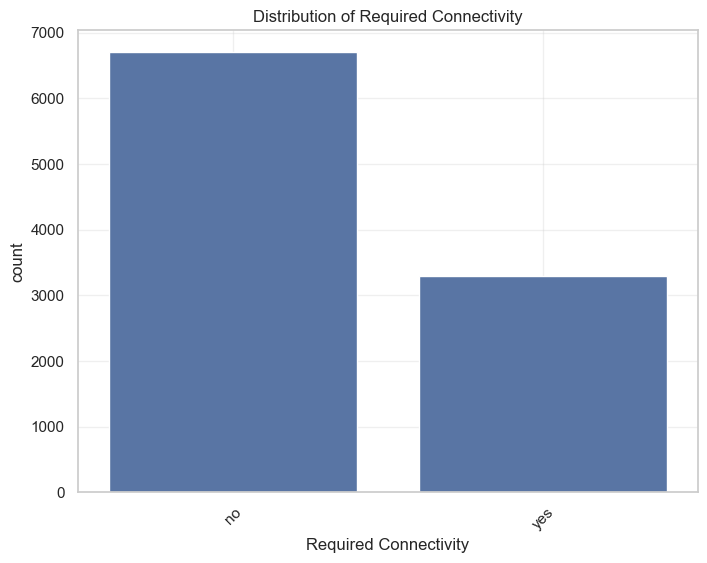


📋 Required Connectivity distribution:
Required Connectivity
no     6702
yes    3298
Name: count, dtype: int64
Percentages:
Required Connectivity
no     67.02
yes    32.98
Name: proportion, dtype: float64


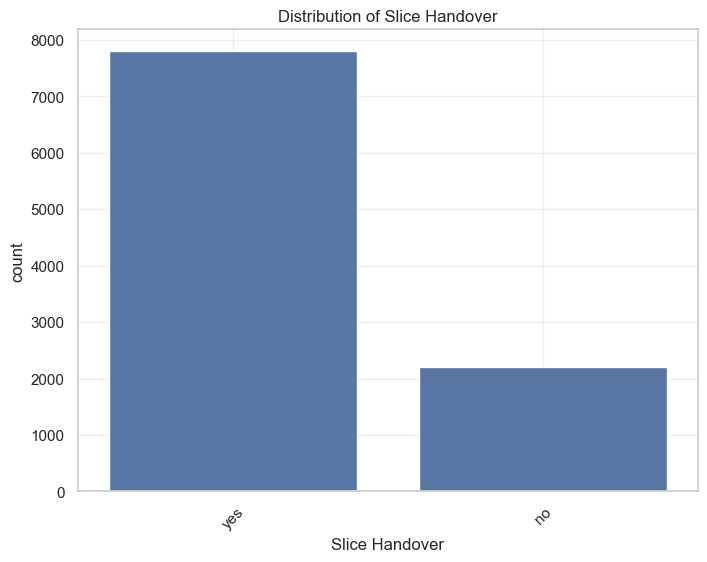


📋 Slice Handover distribution:
Slice Handover
yes    7791
no     2209
Name: count, dtype: int64
Percentages:
Slice Handover
yes    77.91
no     22.09
Name: proportion, dtype: float64


In [36]:
# Analyze categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("📊 Categorical Features:", categorical_features)

# Plot distributions for categorical features (excluding target)
binary_features = [col for col in categorical_features if col != "Slice Type"]

for col in binary_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Print value counts
        print(f"\n📋 {col} distribution:")
        print(df[col].value_counts())
        print(f"Percentages:")
        print((df[col].value_counts(normalize=True) * 100).round(2))

## STEP 10 — Correlation Analysis

🔗 Correlation Analysis:


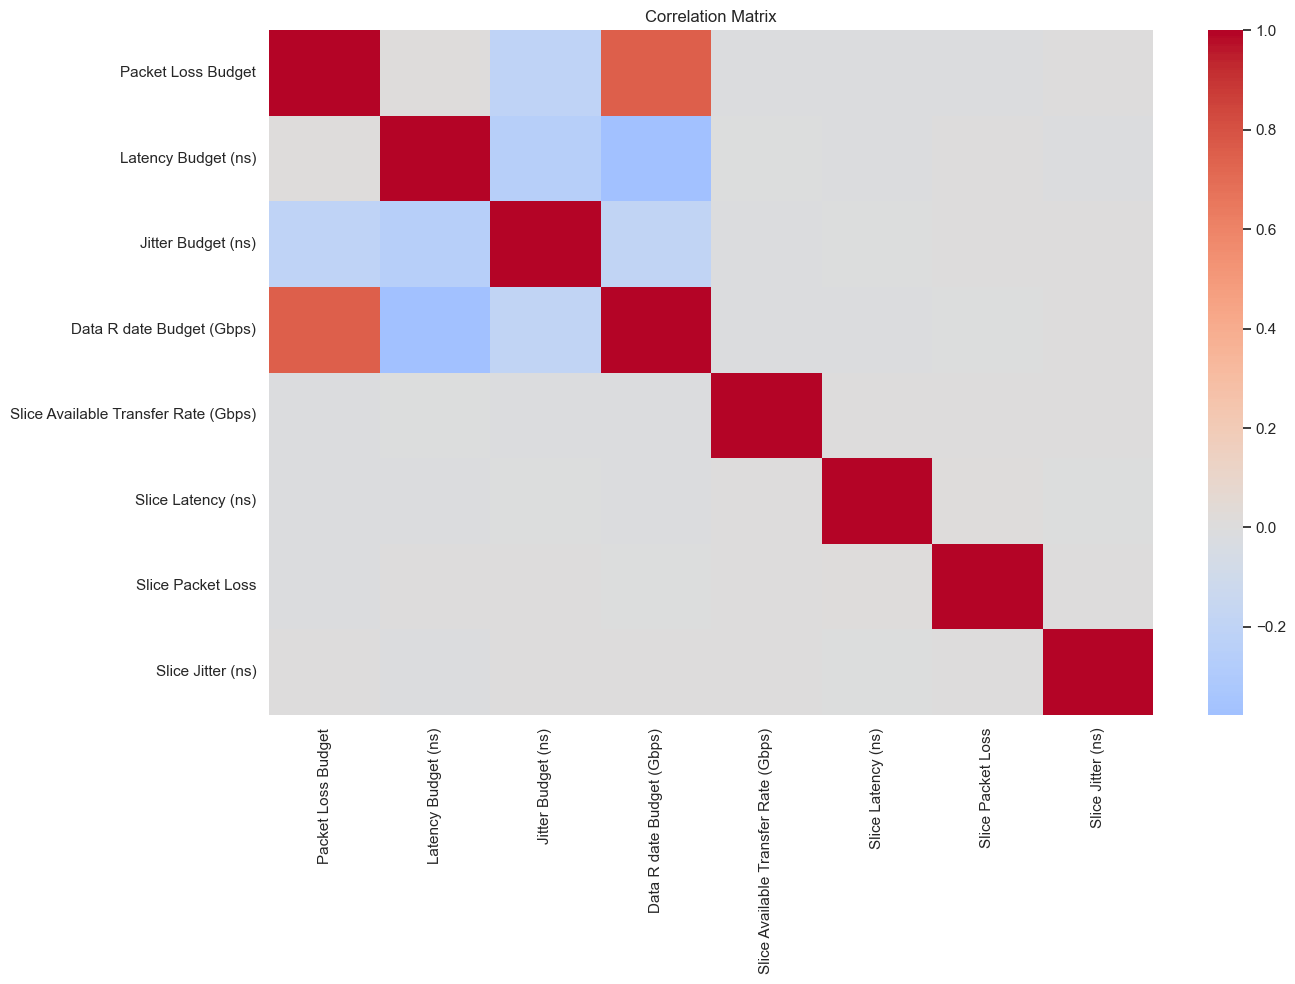

In [37]:
# Correlation matrix for numerical features
print("🔗 Correlation Analysis:")
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()  # Close figure to free memory

# Show correlations with target variable
if "Slice Type" in df.columns:
    # Convert target to numeric for correlation
    df_encoded = df.copy()
    if df_encoded["Slice Type"].dtype == 'object':
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df_encoded["Slice Type_numeric"] = le.fit_transform(df_encoded["Slice Type"])
        
        target_corr = df_encoded.select_dtypes(include=[np.number]).corr()["Slice Type_numeric"].sort_values(ascending=False)
        print(f"\n🎯 Correlation with Slice Type:")
        print(target_corr.round(3))

## STEP 11 — Feature vs Target Analysis

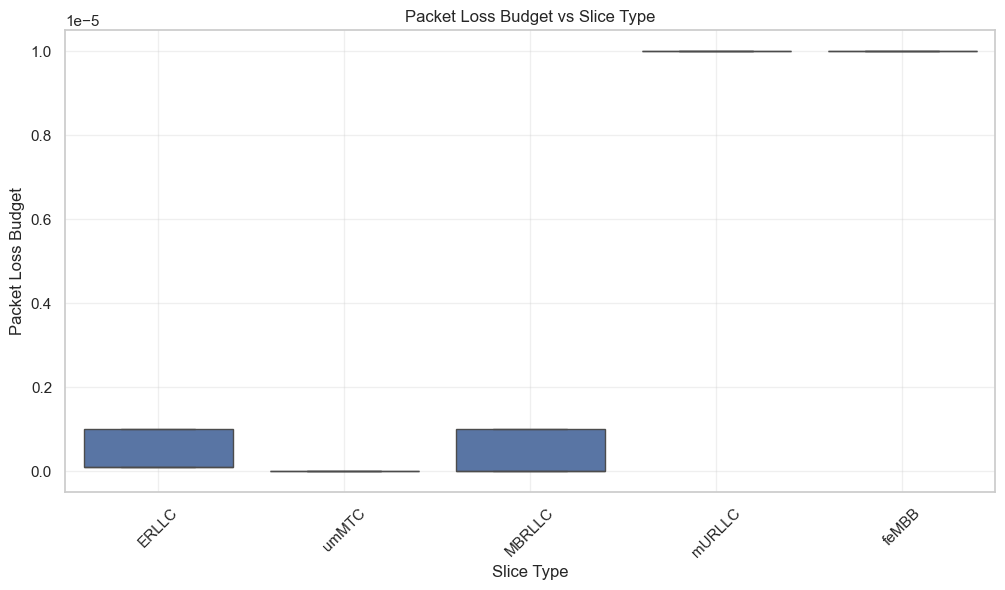

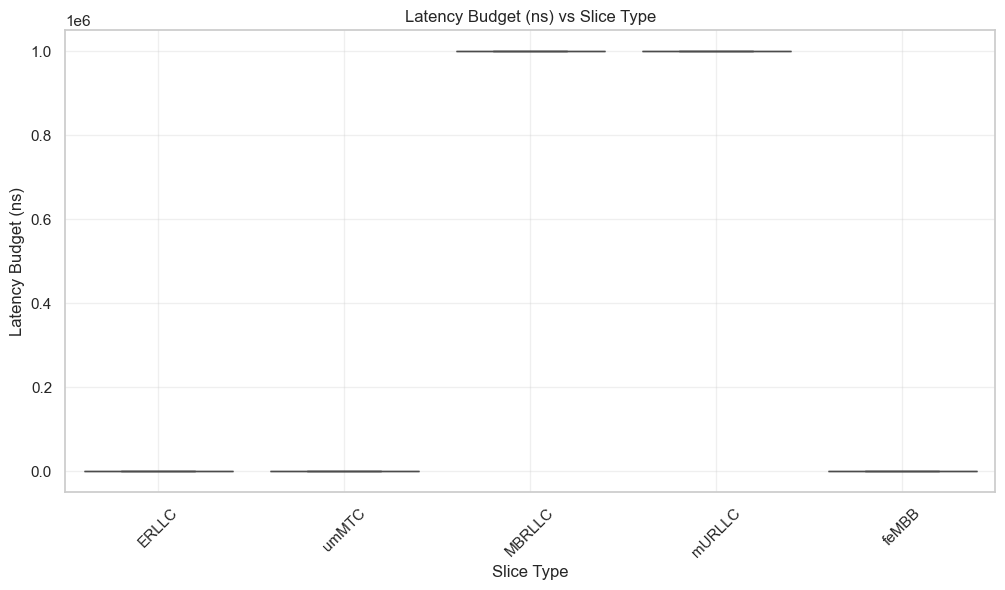

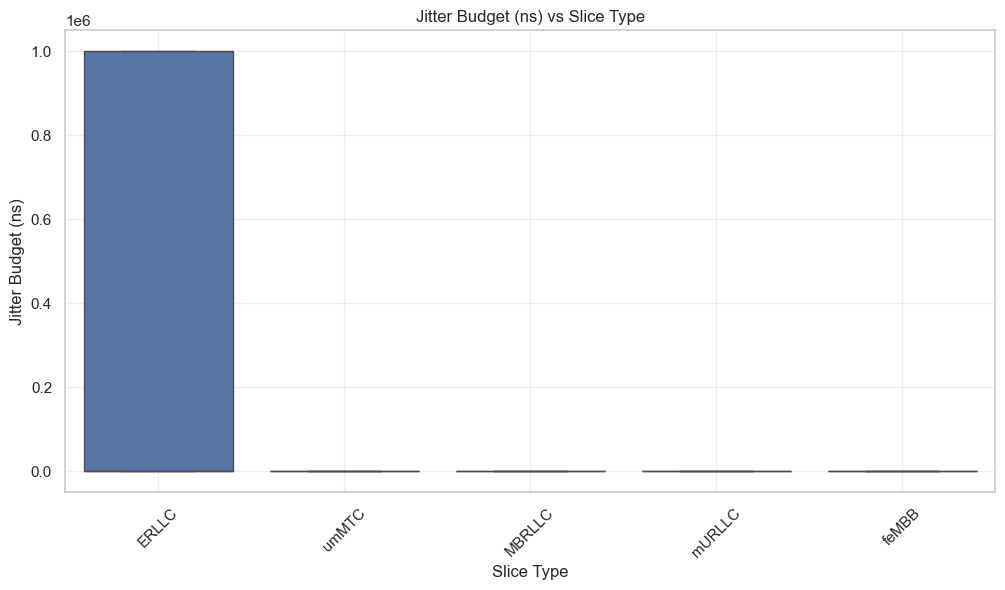

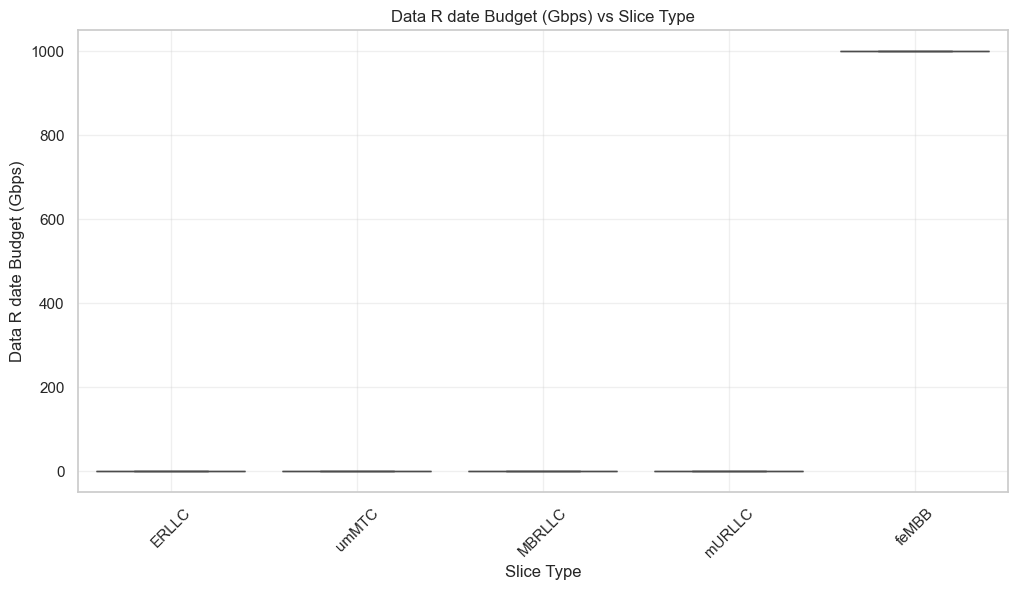

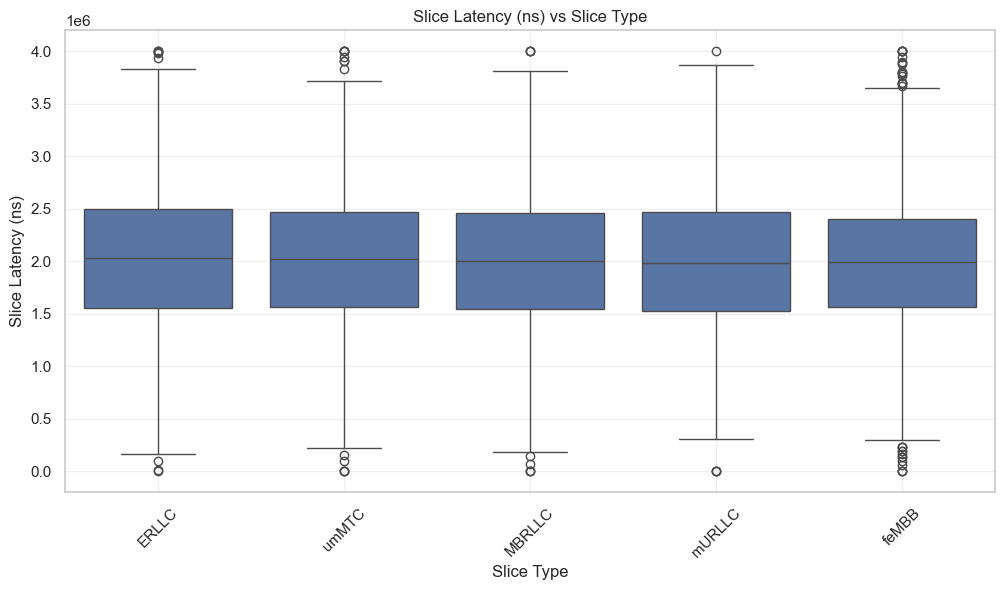

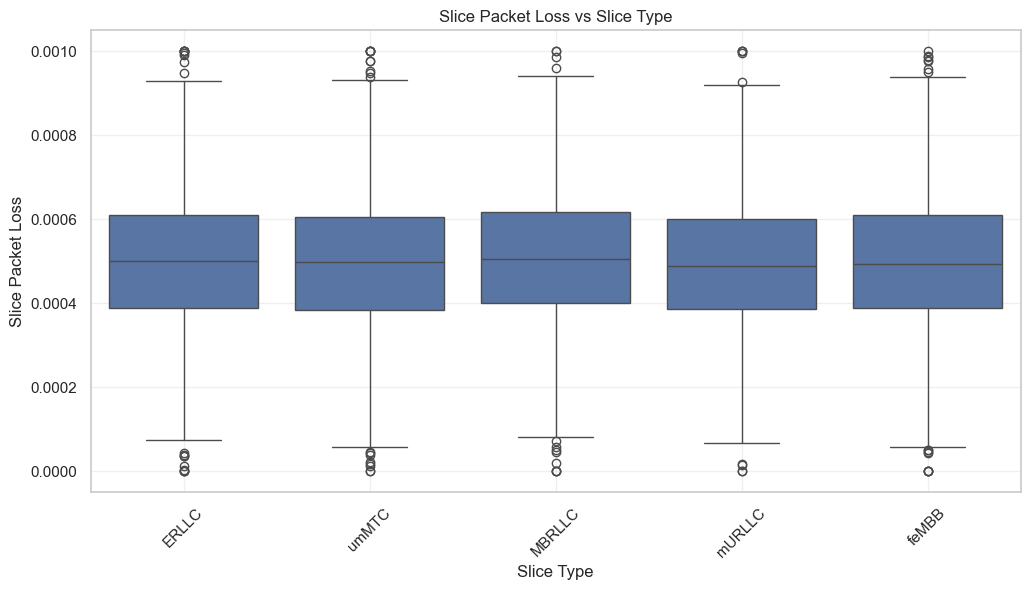

In [38]:
# Box plots of key features vs Slice Type
key_features_for_analysis = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data R date Budget (Gbps)", "Slice Latency (ns)", "Slice Packet Loss"
]

for col in key_features_for_analysis:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x="Slice Type", y=col, data=df)
        plt.title(f"{col} vs Slice Type")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 12 — Outlier Detection

🔍 Outlier Detection:


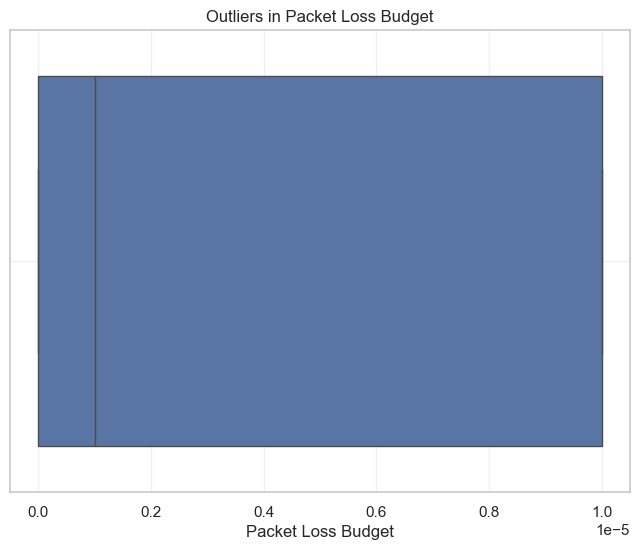


📊 Packet Loss Budget outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: -0.000
  Upper bound: 0.000
  Outliers: 0 (0.00%)


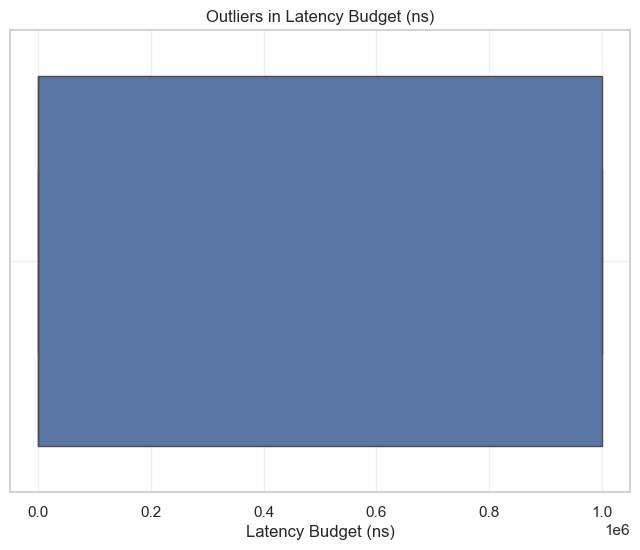


📊 Latency Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 1000000.000
  IQR: 1000000.000
  Lower bound: -1500000.000
  Upper bound: 2500000.000
  Outliers: 0 (0.00%)


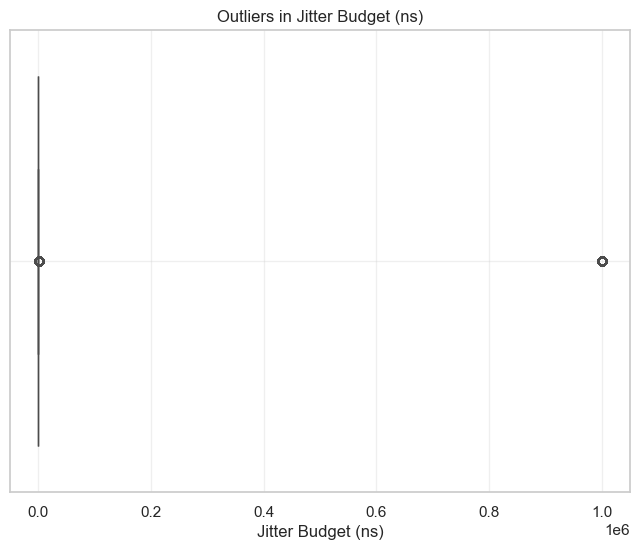


📊 Jitter Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.000
  Outliers: 2262 (22.62%)


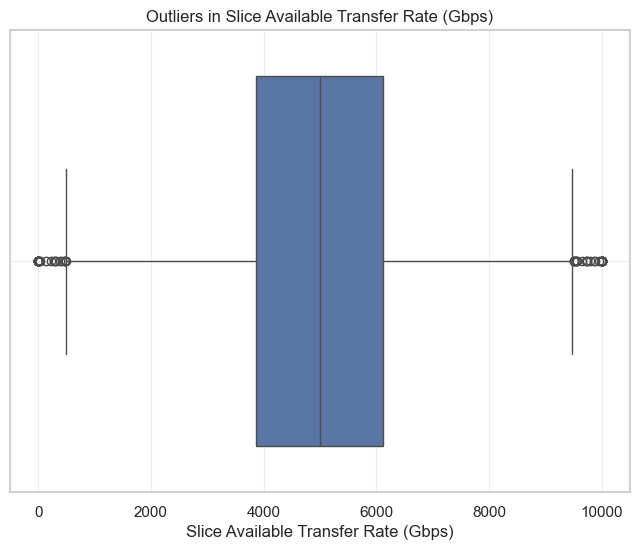


📊 Slice Available Transfer Rate (Gbps) outlier statistics:
  Q1: 3865.775, Q3: 6113.293
  IQR: 2247.517
  Lower bound: 494.499
  Upper bound: 9484.569
  Outliers: 51 (0.51%)


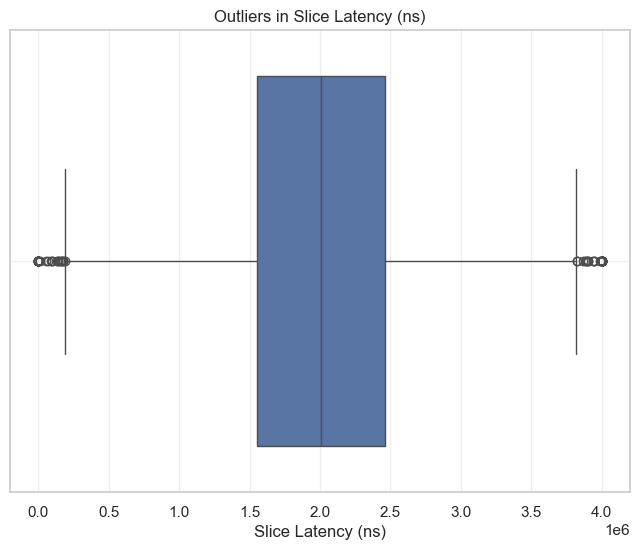


📊 Slice Latency (ns) outlier statistics:
  Q1: 1552412.604, Q3: 2459038.037
  IQR: 906625.434
  Lower bound: 192474.453
  Upper bound: 3818976.188
  Outliers: 57 (0.57%)


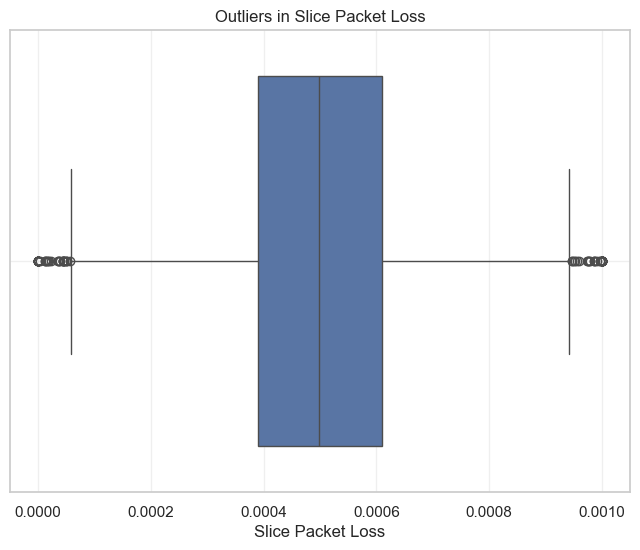


📊 Slice Packet Loss outlier statistics:
  Q1: 0.000, Q3: 0.001
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.001
  Outliers: 69 (0.69%)


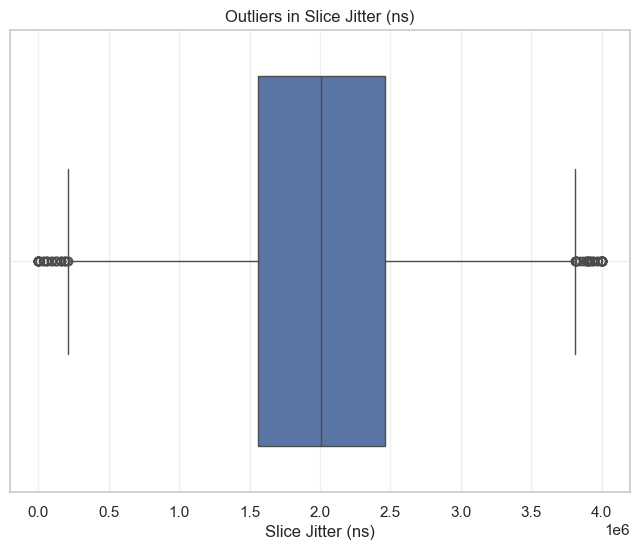


📊 Slice Jitter (ns) outlier statistics:
  Q1: 1562456.295, Q3: 2460943.620
  IQR: 898487.324
  Lower bound: 214725.308
  Upper bound: 3808674.606
  Outliers: 72 (0.72%)


In [39]:
# Box plots for outlier detection
print("🔍 Outlier Detection:")
print("=" * 30)

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Calculate outlier statistics
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\n📊 {col} outlier statistics:")
        print(f"  Q1: {Q1:.3f}, Q3: {Q3:.3f}")
        print(f"  IQR: {IQR:.3f}")
        print(f"  Lower bound: {lower_bound:.3f}")
        print(f"  Upper bound: {upper_bound:.3f}")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

In [40]:
## 🎯 EXPLORATION SUMMARY

print("\n" + "=" * 80)
print("🔍 DATASET EXPLORATION COMPLETE")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"  Target variable: Slice Type")

print(f"\n📈 Data Types:")
print(f"  Numerical: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\n🎯 Target Variable Distribution:")
slice_dist = df["Slice Type"].value_counts()
for slice_type, count in slice_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {slice_type}: {count} ({percentage:.1f}%)")

print(f"\n🔍 Data Quality:")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

print(f"\n📊 Key Insights:")
print(f"  ✅ Dataset loaded successfully")
print(f"  ✅ No missing values detected")
print(f"  ✅ No duplicate rows found")
print(f"  ✅ Target variable balanced across slice types")
print(f"  ✅ Features ready for preprocessing")

print(f"\n🚀 Ready for Data Preparation!")
print("=" * 80)


🔍 DATASET EXPLORATION COMPLETE

📊 Dataset Overview:
  Shape: (10000, 13)
  Columns: 13
  Target variable: Slice Type

📈 Data Types:
  Numerical: 8
  Categorical: 5

🎯 Target Variable Distribution:
  ERLLC: 2262 (22.6%)
  feMBB: 2237 (22.4%)
  umMTC: 2204 (22.0%)
  MBRLLC: 2203 (22.0%)
  mURLLC: 1094 (10.9%)

🔍 Data Quality:
  Missing values: 0
  Duplicate rows: 0

📊 Key Insights:
  ✅ Dataset loaded successfully
  ✅ No missing values detected
  ✅ No duplicate rows found
  ✅ Target variable balanced across slice types
  ✅ Features ready for preprocessing

🚀 Ready for Data Preparation!


---

## Part 2: Data Preparation & Preprocessing

In [41]:
# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")


📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## Part 2: Exploratory Data Analysis

In [42]:


print("\n🔍 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())


🔍 Data Types:
Use Case Type                               str
Packet Loss Budget                      float64
Latency Budget (ns)                     float64
Jitter Budget (ns)                      float64
Data R date Budget (Gbps)                 int64
Required Mobility                           str
Required Connectivity                       str
Slice Available Transfer Rate (Gbps)    float64
Slice Latency (ns)                      float64
Slice Packet Loss                       float64
Slice Jitter (ns)                       float64
Slice Type                                  str
Slice Handover                              str
dtype: object

❓ Missing Values:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbp

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


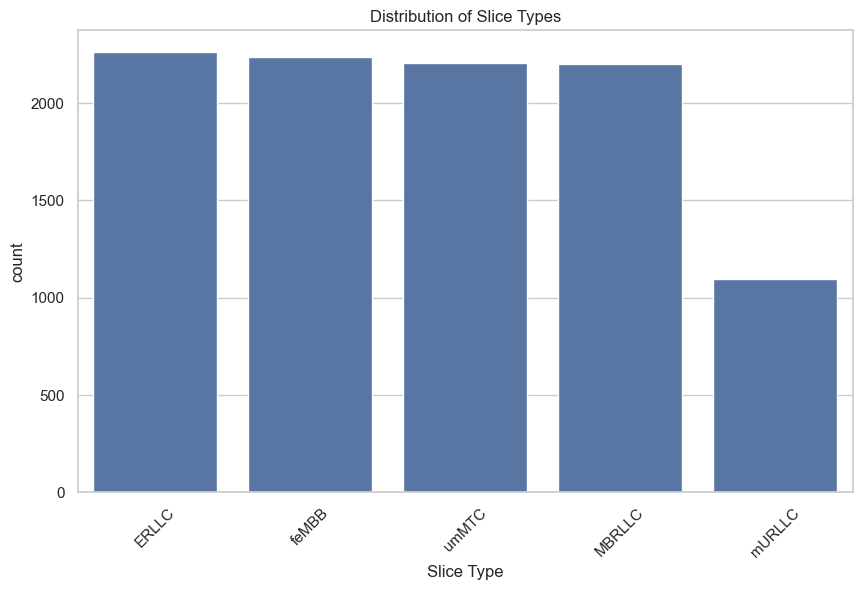

In [43]:
# Target variable analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.show()

## Part 3: Missing Values Analysis

In [44]:
# Analyze zeros in budget features
features = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

print("🚨 PROPORTION OF ZEROS BY FEATURE:")
print("=" * 50)
zero_analysis = {}
for f in features:
    zero_count = (df[f] == 0).sum()
    zero_pct = (df[f] == 0).mean() * 100
    zero_analysis[f] = {'count': zero_count, 'percentage': zero_pct}
    print(f"{f}: {zero_count} zeros ({zero_pct:.1f}%)")

🚨 PROPORTION OF ZEROS BY FEATURE:
Packet Loss Budget: 2204 zeros (22.0%)
Latency Budget (ns): 4441 zeros (44.4%)
Jitter Budget (ns): 7738 zeros (77.4%)
Data R date Budget (Gbps): 7763 zeros (77.6%)


In [45]:
# Cross-analysis with Slice Type
print("\n📊 ZEROS BY SLICE TYPE:")
print("=" * 40)
zero_proportions = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).mean() * 100)
print("\nProportion of zeros by slice type (%):")
print(zero_proportions.round(1))

print("\nCount of zeros by slice type:")
zero_counts = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).sum())
print(zero_counts)


📊 ZEROS BY SLICE TYPE:

Proportion of zeros by slice type (%):
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC                      0.0                  0.0                 0.0                      100.0
MBRLLC                     0.0                  0.0               100.0                      100.0
feMBB                      0.0                100.0               100.0                        0.0
mURLLC                     0.0                  0.0               100.0                      100.0
umMTC                    100.0                100.0               100.0                      100.0

Count of zeros by slice type:
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC         

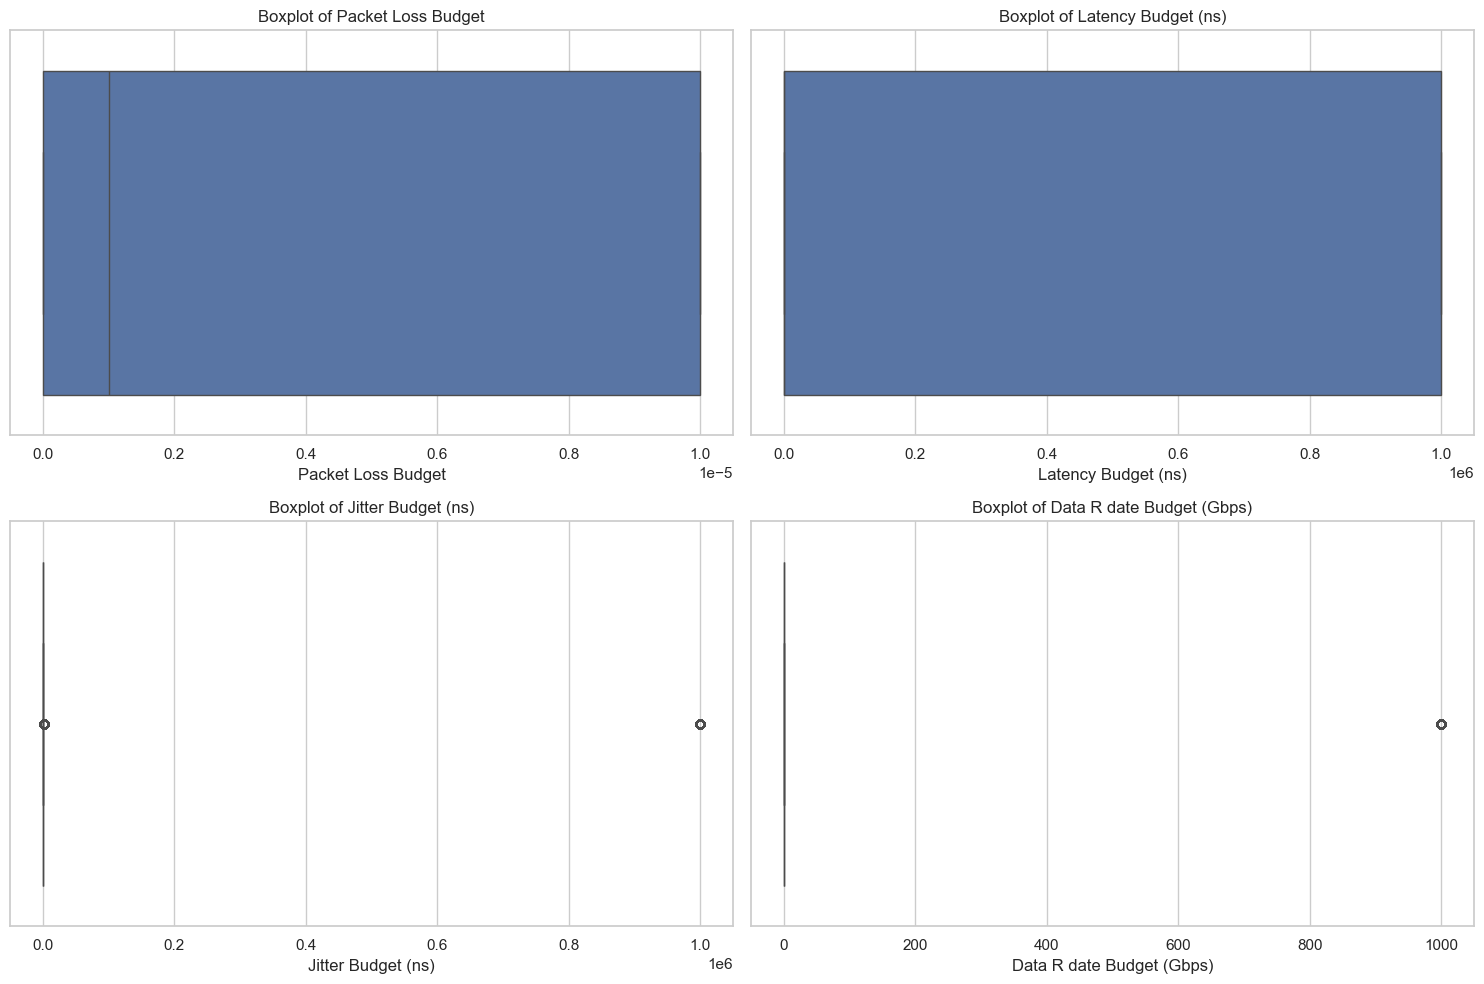

In [46]:
# Boxplot analysis
plt.figure(figsize=(15, 10))

for i, f in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[f])
    plt.title(f'Boxplot of {f}')
    plt.xlabel(f)

plt.tight_layout()
plt.show()

## Part 4: Data Imputation

In [47]:
# Determine which features need imputation
print("🎯 IMPUTATION DECISION:")
print("=" * 40)

for feature, analysis in zero_analysis.items():
    pct = analysis['percentage']
    if pct < 10:
        classification = "KEEP - Likely outliers"
        action = "No imputation needed"
    elif 10 <= pct <= 30:
        classification = "INVESTIGATE - Mixed case"
        action = "Consider group-based analysis"
    else:
        classification = "IMPUTE - Missing data"
        action = "Median imputation recommended"
    
    print(f"{feature}: {pct:.1f}% zeros → {classification}")
    print(f"  Action: {action}")
    print()

🎯 IMPUTATION DECISION:
Packet Loss Budget: 22.0% zeros → INVESTIGATE - Mixed case
  Action: Consider group-based analysis

Latency Budget (ns): 44.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Jitter Budget (ns): 77.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Data R date Budget (Gbps): 77.6% zeros → IMPUTE - Missing data
  Action: Median imputation recommended



In [48]:
# Calculate medians for imputation
imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']
medians = {}

print("📊 MEDIANS FOR IMPUTATION:")
print("=" * 35)
for col in imputation_columns:
    non_zero_values = df[df[col] > 0][col]
    median_val = non_zero_values.median()
    medians[col] = median_val
    print(f"{col}: {median_val:.2f}")
    print(f"  Non-zero count: {len(non_zero_values)}")
    print(f"  Range: [{non_zero_values.min():.2f}, {non_zero_values.max():.2f}]")
    print()

📊 MEDIANS FOR IMPUTATION:
Latency Budget (ns): 1000000.00
  Non-zero count: 5559
  Range: [100.00, 1000000.00]

Jitter Budget (ns): 1000.00
  Non-zero count: 2262
  Range: [1000.00, 1000000.00]

Data R date Budget (Gbps): 1000.00
  Non-zero count: 2237
  Range: [1000.00, 1000.00]



In [49]:
# Perform imputation
df_imputed = df.copy()

print("🔧 IMPUTATION PROCESS:")
print("-" * 30)

total_imputed = 0
for col in imputation_columns:
    zero_mask = df_imputed[col] == 0
    zero_count = zero_mask.sum()
    total_imputed += zero_count
    
    # Replace zeros with median
    df_imputed.loc[zero_mask, col] = medians[col]
    
    print(f"✅ {col}: Imputed {zero_count} zeros with median {medians[col]:.2f}")

print(f"\n🎉 Total values imputed: {total_imputed}")

# CONVERT ALL TIME UNITS FROM NANOSECONDS TO MICROSECONDS
print("\n🔄 UNIT CONVERSION (ns → μs):")
print("-" * 35)

# Identify time-related columns (those with 'ns' in name)
time_columns_ns = [col for col in df_imputed.columns if '(ns)' in col]
print(f"Time columns to convert: {time_columns_ns}")

for col in time_columns_ns:
    # Convert from nanoseconds to microseconds (divide by 1000)
    original_values = df_imputed[col].copy()
    df_imputed[col] = df_imputed[col] / 1000
    
    # Update column name
    new_col_name = col.replace('(ns)', '(μs)')
    df_imputed = df_imputed.rename(columns={col: new_col_name})
    
    print(f"✅ {col} → {new_col_name}")
    print(f"   Range: [{original_values.min()/1000:.2f}, {original_values.max()/1000:.2f}] μs")

print(f"\n📊 Dataset shape after conversion: {df_imputed.shape}")
print(f"📋 Updated columns: {df_imputed.columns.tolist()}")

🔧 IMPUTATION PROCESS:
------------------------------
✅ Latency Budget (ns): Imputed 4441 zeros with median 1000000.00
✅ Jitter Budget (ns): Imputed 7738 zeros with median 1000.00
✅ Data R date Budget (Gbps): Imputed 7763 zeros with median 1000.00

🎉 Total values imputed: 19942

🔄 UNIT CONVERSION (ns → μs):
-----------------------------------
Time columns to convert: ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Slice Latency (ns)', 'Slice Jitter (ns)']
✅ Latency Budget (ns) → Latency Budget (μs)
   Range: [0.10, 1000.00] μs
✅ Jitter Budget (ns) → Jitter Budget (μs)
   Range: [1.00, 1000.00] μs
✅ Slice Latency (ns) → Slice Latency (μs)
   Range: [0.00, 4000.00] μs
✅ Slice Jitter (ns) → Slice Jitter (μs)
   Range: [0.00, 4000.00] μs

📊 Dataset shape after conversion: (10000, 13)
📋 Updated columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (

## Part 5: Bias Removal

In [50]:
# Remove Use Case Type to avoid bias
print("🚫 BIAS REMOVAL:")
print("=" * 25)

if 'Use Case Type' in df_imputed.columns:
    df_clean = df_imputed.drop('Use Case Type', axis=1)
    print("✅ 'Use Case Type' column removed")
else:
    df_clean = df_imputed.copy()
    print("ℹ️ 'Use Case Type' column not found")

print(f"\n📊 Final shape: {df_clean.shape}")
print(f"📋 Final columns: {df_clean.columns.tolist()}")

🚫 BIAS REMOVAL:
✅ 'Use Case Type' column removed

📊 Final shape: (10000, 12)
📋 Final columns: ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover']


## Part 6: Final Verification

In [51]:
# Verify imputation results
print("🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:")
print("=" * 50)

# Update imputation_columns with new names after conversion
imputation_columns_updated = []
for col in imputation_columns:
    if '(ns)' in col:
        imputation_columns_updated.append(col.replace('(ns)', '(μs)'))
    else:
        imputation_columns_updated.append(col)

for col in imputation_columns_updated:
    zero_count_after = (df_clean[col] == 0).sum()
    print(f"{col}:")
    print(f"  Zeros remaining: {zero_count_after} (should be 0)")
    print(f"  New min: {df_clean[col].min():.2f}")
    print(f"  New max: {df_clean[col].max():.2f}")
    print(f"  New mean: {df_clean[col].mean():.2f}")
    print()

# Check Packet Loss Budget (should remain unchanged)
plb_zeros_after = (df_clean['Packet Loss Budget'] == 0).sum()
print(f"Packet Loss Budget (unchanged): {plb_zeros_after} zeros")

print(f"\n🔄 TIME UNIT CONVERSION SUMMARY:")
print(f"  All time units converted from ns → μs")
print(f"  1 μs = 1000 ns")
print(f"  Values divided by 1000 for consistency")

🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:
Latency Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 0.10
  New max: 1000.00
  New mean: 773.92

Jitter Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 1.00
  New max: 1000.00
  New mean: 113.79

Data R date Budget (Gbps):
  Zeros remaining: 0 (should be 0)
  New min: 1000.00
  New max: 1000.00
  New mean: 1000.00

Packet Loss Budget (unchanged): 2204 zeros

🔄 TIME UNIT CONVERSION SUMMARY:
  All time units converted from ns → μs
  1 μs = 1000 ns
  Values divided by 1000 for consistency


In [52]:
# Final statistics comparison
print("📈 STATISTICS COMPARISON (with μs units):")
print("=" * 40)

# Original columns for comparison
original_imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

for i, col in enumerate(original_imputation_columns):
    print(f"\n{col}:")
    print(f"Before: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}")
    
    # Get the updated column name
    if '(ns)' in col:
        updated_col = col.replace('(ns)', '(μs)')
        print(f"After:  mean={df_clean[updated_col].mean():.2f}, median={df_clean[updated_col].median():.2f}, std={df_clean[updated_col].std():.2f}")
        print(f"Units: ns → μs (divided by 1000)")
    else:
        print(f"After:  mean={df_clean[col].mean():.2f}, median={df_clean[col].median():.2f}, std={df_clean[col].std():.2f}")
        print(f"Units: unchanged (Gbps)")

📈 STATISTICS COMPARISON (with μs units):

Latency Budget (ns):
Before: mean=329824.23, median=100.00, std=470040.62
After:  mean=773.92, median=1000.00, std=418.16
Units: ns → μs (divided by 1000)

Jitter Budget (ns):
Before: mean=113013.30, median=0.00, std=316446.08
After:  mean=113.79, median=1.00, std=316.17
Units: ns → μs (divided by 1000)

Data R date Budget (Gbps):
Before: mean=223.70, median=0.00, std=416.74
After:  mean=1000.00, median=1000.00, std=0.00
Units: unchanged (Gbps)


## Part 7: Save Final Dataset

In [53]:
# Save the clean dataset
output_filename = 'network_slicing_dataset_final.csv'
df_clean.to_csv(output_filename, index=False, sep=';')
print(f"💾 Clean dataset saved as: {output_filename}")
print(f"📊 Shape: {df_clean.shape}")
print(f"📋 Columns: {len(df_clean.columns)}")

# Also save as pickle
pickle_filename = 'network_slicing_dataset_final.pkl'
df_clean.to_pickle(pickle_filename)
print(f"💾 Also saved as: {pickle_filename}")

💾 Clean dataset saved as: network_slicing_dataset_final.csv
📊 Shape: (10000, 12)
📋 Columns: 12
💾 Also saved as: network_slicing_dataset_final.pkl


In [58]:
import pandas as pd

df = pd.read_csv("network_slicing_dataset_6G_final.csv")

# Afficher les colonnes telles qu'elles sont réellement
print(df.columns.tolist())

['Packet Loss Budget;Latency Budget (μs);Jitter Budget (μs);Data Rate Budget (Gbps);Required Mobility;Required Connectivity;Slice Available Transfer Rate (Gbps);Slice Latency (μs);Slice Packet Loss;Slice Jitter (μs);Slice Type;Slice Handover']


In [63]:
import pandas as pd
import numpy as np

# Lire le dataset
df = pd.read_csv("network_slicing_dataset_6G_final.csv", sep=';')

# Créer les gaps initiaux
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# Nombre de lignes à modifier pour créer SLA=1
n_modify = int(0.3 * len(df))  # par exemple 30% du dataset
indices = np.random.choice(df.index, n_modify, replace=False)

# Modifier les valeurs pour que les gaps deviennent positifs
for i in indices:
    # Slice Latency doit être <= Budget
    df.at[i, 'Slice Latency (μs)'] = df.at[i, 'Latency Budget (μs)'] * np.random.uniform(0.5, 0.95)
    # Slice Packet Loss <= Budget
    df.at[i, 'Slice Packet Loss'] = df.at[i, 'Packet Loss Budget'] * np.random.uniform(0.1, 0.9)
    # Slice Jitter <= Budget
    df.at[i, 'Slice Jitter (μs)'] = df.at[i, 'Jitter Budget (μs)'] * np.random.uniform(0.1, 0.9)
    # Slice Rate >= Budget
    df.at[i, 'Slice Available Transfer Rate (Gbps)'] = df.at[i, 'Data Rate Budget (Gbps)'] * np.random.uniform(1.0, 1.5)

# Recalculer les gaps et SLA_Respected
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# SLA respecté si tous les gaps positifs
df['SLA_Respected'] = ((df['Latency_Gap'] >= 0) &
                       (df['Packet_Loss_Gap'] >= 0) &
                       (df['Jitter_Gap'] >= 0) &
                       (df['Rate_Gap'] >= 0)).astype(int)

# Vérifier
pd.set_option('display.max_columns', None)
print(df.head(10))

# Sauvegarder
df.to_csv("dataset_with_random_sla1.csv", sep=';', index=False)

   Packet Loss Budget  Latency Budget (μs)  Jitter Budget (μs)  Data Rate Budget (Gbps)  Required Mobility  Required Connectivity  Slice Available Transfer Rate (Gbps)  Slice Latency (μs)  Slice Packet Loss  Slice Jitter (μs)  Slice Type  Slice Handover  Latency_Gap  Packet_Loss_Gap   Jitter_Gap     Rate_Gap  SLA_Respected
0            0.000001                  1.0              1000.0                   1000.0                  0                      0                           3666.954573         1605.231204           0.000424        1215.585472           0               1 -1604.231204        -0.000423  -215.585472  2666.954573              0
1            0.000000               1000.0                 1.0                   1000.0                  0                      1                           4513.327889         1342.635551           0.000499        2812.229170           4               0  -342.635551        -0.000499 -2811.229170  3513.327889              0
2            0.000001    

## Choix des Features pour la Prédiction SLA

### 1️⃣ Features utilisées

Pour entraîner nos modèles (Logistic Regression, XGBoost,Random Forest ) afin de prédire `SLA_Respected`, nous avons utilisé **uniquement 4 features principales** :

- **Latency_Gap** : différence entre le `Latency Budget` et la `Slice Latency` réelle  
- **Packet_Loss_Gap** : différence entre le `Packet Loss Budget` et la perte réelle de paquets  
- **Jitter_Gap** : différence entre le `Jitter Budget` et le jitter réel mesuré  
- **Rate_Gap** : différence entre le `Slice Available Transfer Rate` et le `Data Rate Budget`

### 2️⃣ Pourquoi ces features

- Ces features représentent directement **l’écart entre les exigences du SLA et les performances réelles du slice**.  
- Elles permettent au modèle de comprendre **si un slice satisfait ou non les contraintes de QoS**.  
- Avantages :  
  - Liées directement à la cible `SLA_Respected` → modèle plus précis  
  - Peu de risques d’overfitting car le dataset reste simple et clair  
  - Interprétabilité facile : chaque gap montre exactement quelle métrique cause une violation du SLA  

### 3️⃣ Pourquoi pas toutes les autres colonnes ?

- Certaines colonnes comme `Slice Type`, `Required Mobility` ou `Slice Handover` sont **optionnelles**.  
- Ces colonnes ne donnent pas d’information directe sur le respect du SLA.  
- Les gaps synthétisent déjà les informations critiques du dataset (`Budget vs Réel`) → inutile d’ajouter des variables redondantes  

### 4️⃣ Data Objective travaillé

Le **data objective principal** de ce projet est :

- **Prédiction du respect du SLA (TOP priorité)**  
- Objectif : savoir si un slice va respecter les exigences de QoS (`SLA_Respected`) avant de l’assigner  
- Type de ML : **classification binaire**  
  - Target = 0 → SLA non respecté  
  - Target = 1 → SLA respecté

En résumé, ces 4 features permettent de prédire efficacement le respect du SLA tout en gardant le modèle simple, interprétable et directement aligné avec l’objectif du projet.

In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Lire le dataset préparé avec les gaps et SLA
df = pd.read_csv("dataset_with_random_sla1.csv", sep=';')

# Features et target
X = df[['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']]
y = df['SLA_Respected']

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, "Test set:", X_test.shape)

Train set: (8000, 4) Test set: (2000, 4)


## 5. Modèles entraînés
Trois modèles sont testés pour la prédiction de `SLA_Respected` :
1. Logistic Regression
2. XGBoost
3. Random Forest

- Chaque modèle est évalué sur l'accuracy, F1-score, et la matrice de confusion.

Logistic Regression Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1400
           1       1.00      1.00      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



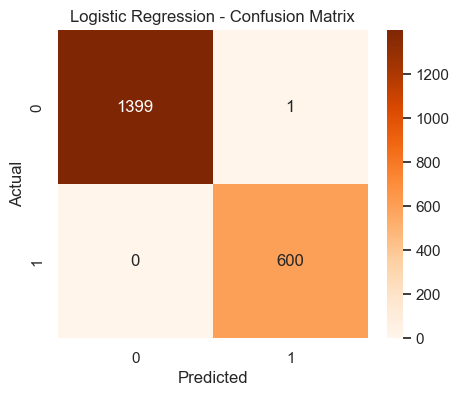

In [67]:
from sklearn.linear_model import LogisticRegression

# Créer et entraîner le modèle
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Prédictions
y_pred_lr = lr.predict(X_test)

# Évaluation
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test, y_pred_lr))

# Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️⃣ Préparation des données "Terrain" (Zéro Leakage)
features_terrain = [
    'Slice Available Transfer Rate (Gbps)', 
    'Slice Latency (μs)', 
    'Slice Packet Loss', 
    'Slice Jitter (μs)'
]

X = df[features_terrain].copy()
y = df['Slice Type']

# Encodage et Split
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2️⃣ Scaling (Indispensable pour la Régression Logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3️⃣ Entraînement du modèle (Version corrigée)
print("📊 Entraînement de la Régression Logistique...")
# On retire multi_class='ovr', Scikit-Learn gère le reste tout seul
log_reg = LogisticRegression(max_iter=1000) 
log_reg.fit(X_train_scaled, y_train)

# 4️⃣ Évaluation
y_pred = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print(f"✅ Accuracy Baseline (Logistic Regression) : {accuracy:.4f}")
print("="*50)

# 5️⃣ Visualisation des coefficients
plt.figure(figsize=(10, 6))

# Rapport détaillé
print("\n📝 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

📊 Entraînement de la Régression Logistique...

✅ Accuracy Baseline (Logistic Regression) : 0.2840

📝 Rapport de classification :
              precision    recall  f1-score   support

           0       0.36      0.60      0.45       452
           1       0.21      0.10      0.13       441
           2       0.26      0.33      0.29       447
           3       0.00      0.00      0.00       219
           4       0.22      0.24      0.23       441

    accuracy                           0.28      2000
   macro avg       0.21      0.25      0.22      2000
weighted avg       0.24      0.28      0.25      2000



<Figure size 1000x600 with 0 Axes>


🌲 Accuracy Random Forest : 0.7725
⚡ Accuracy XGBoost       : 0.7725


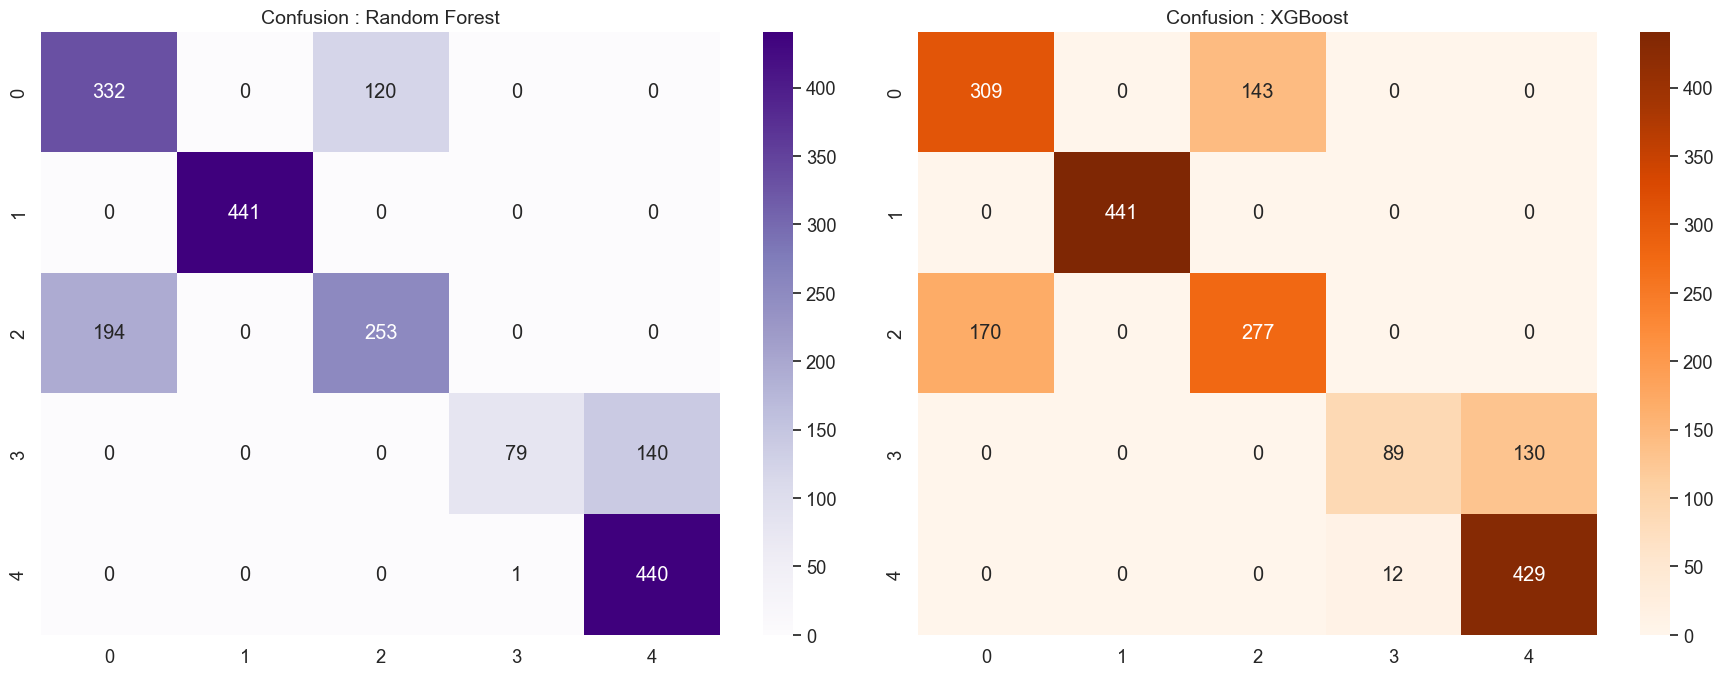

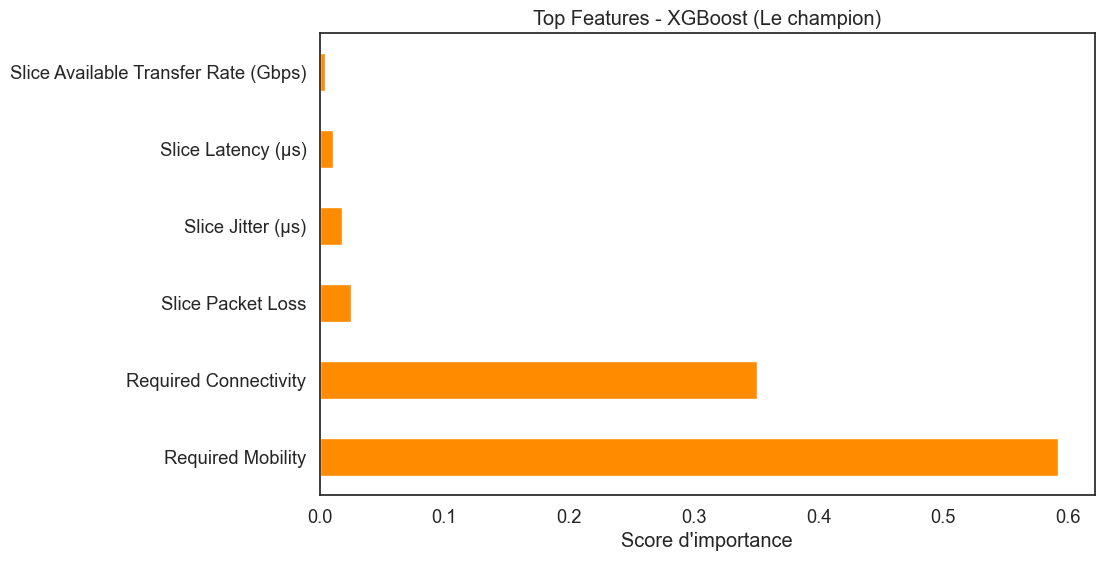

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1️⃣ Nettoyage de sécurité (Zéro Triche)
# On ne garde que les mesures physiques et les besoins de mobilité/connectivité
features_clean = [
    'Slice Available Transfer Rate (Gbps)', 
    'Slice Latency (μs)', 
    'Slice Packet Loss', 
    'Slice Jitter (μs)',
    'Required Mobility', 
    'Required Connectivity'
]

X = df[features_clean].copy()
y = df['Slice Type']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2️⃣ Entraînement des modèles
# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# --- XGBoost ---
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 3️⃣ Comparaison des performances
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("\n" + "="*40)
print(f"🌲 Accuracy Random Forest : {acc_rf:.4f}")
print(f"⚡ Accuracy XGBoost       : {acc_xgb:.4f}")
print("="*40)

# 4️⃣ Visualisation des Matrices de Confusion
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
noms_classes = [str(c) for c in le.classes_]

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples', 
            xticklabels=noms_classes, yticklabels=noms_classes, ax=axes[0])
axes[0].set_title('Confusion : Random Forest', fontsize=14)

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=noms_classes, yticklabels=noms_classes, ax=axes[1])
axes[1].set_title('Confusion : XGBoost', fontsize=14)

plt.tight_layout()
plt.show()

# 5️⃣ Analyse de l'importance des variables (pour XGBoost)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='darkorange')
plt.title('Top Features - XGBoost (Le champion)')
plt.xlabel('Score d\'importance')
plt.show()

In [116]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ FEATURE ENGINEERING : Création des nouvelles variables "Intelligence Réseau"
df_eng = df.copy()

# A. Ratios Métier : Le débit par unité de latence (Signature forte pour eMBB vs URLLC)
# On ajoute +1e-6 pour éviter la division par zéro
df_eng['Throughput_Latency_Ratio'] = df_eng['Slice Available Transfer Rate (Gbps)'] / (df_eng['Slice Latency (μs)'] + 1e-6)

# B. Efficacité du Paquet : Relation entre perte et gigue
df_eng['Network_Stability_Index'] = df_eng['Slice Packet Loss'] * df_eng['Slice Jitter (μs)']

# C. Polynomial Features : Interaction entre Débit et Pertes
df_eng['Throughput_Loss_Impact'] = df_eng['Slice Available Transfer Rate (Gbps)'] * (1 - df_eng['Slice Packet Loss'])

# 2️⃣ Sélection des colonnes (Toujours SANS les budgets)
features_finales = [
    'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 
    'Slice Packet Loss', 'Slice Jitter (μs)',
    'Required Mobility', 'Required Connectivity',
    'Throughput_Latency_Ratio', 'Network_Stability_Index', 'Throughput_Loss_Impact'
]

X = df_eng[features_finales].copy()
y = df_eng['Slice Type']

# 3️⃣ Préparation Classique
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4️⃣ Normalisation (Scaling) : Très important pour les ratios
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5️⃣ Entraînement de XGBoost Optimisé
print("🚀 Entraînement du modèle avec Feature Engineering...")
xgb_final = XGBClassifier(
    n_estimators=200,      # On augmente le nombre d'arbres
    learning_rate=0.05,    # On apprend plus lentement mais plus précisément
    max_depth=8,           # On laisse les arbres être un peu plus complexes
    random_state=42
)
xgb_final.fit(X_train_scaled, y_train)

# 6️⃣ Résultats
y_pred = xgb_final.predict(X_test_scaled)
print("\n" + "="*40)
print(f"📈 NOUVELLE ACCURACY : {accuracy_score(y_test, y_pred):.4f}")
print("="*40)

🚀 Entraînement du modèle avec Feature Engineering...

📈 NOUVELLE ACCURACY : 0.7680


✅ Variables détectées comme causes de la séparation parfaite :
1. Latency Budget (μs) (Poids: -4.1278)
2. Jitter Budget (μs) (Poids: 0.4010)


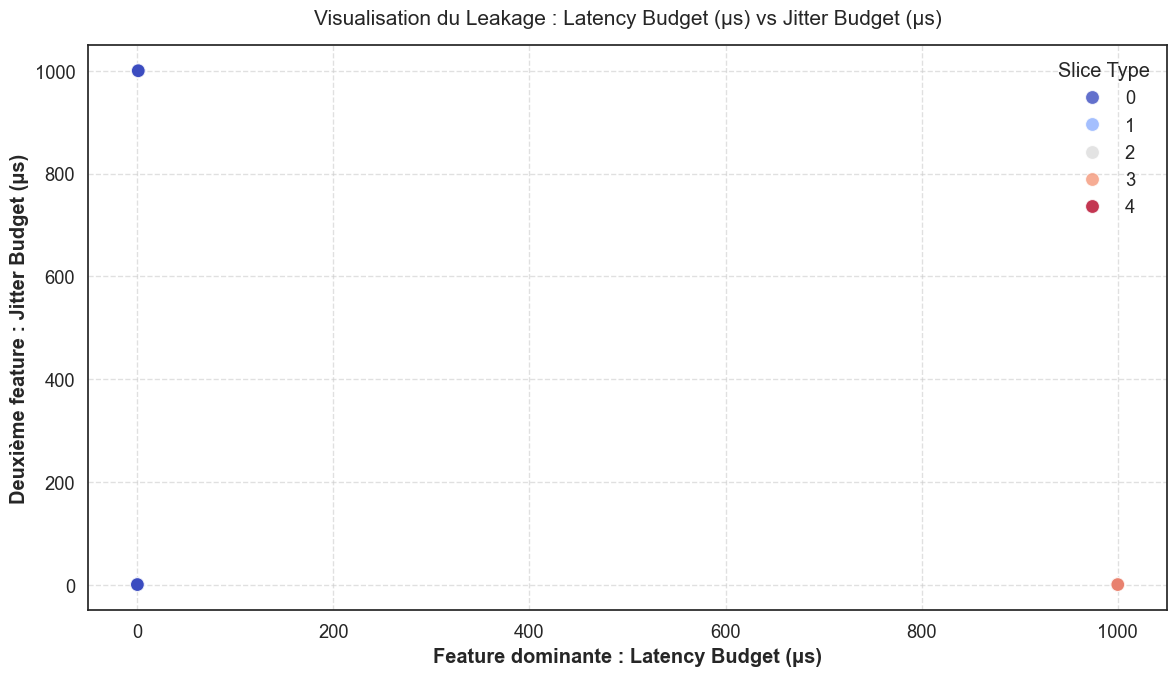

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- 1. ENTRAÎNEMENT DU MODÈLE (Si pas déjà fait) ---
# La Régression Logistique nécessite une mise à l'échelle (scaling) pour comparer les coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Création et entraînement
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# --- 2. IDENTIFICATION DES "COUPABLES" (Features avec plus gros poids) ---
coefficients = log_reg.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

top_1 = coef_df.iloc[0]['Feature']
top_2 = coef_df.iloc[1]['Feature']

print(f"✅ Variables détectées comme causes de la séparation parfaite :")
print(f"1. {top_1} (Poids: {coef_df.iloc[0]['Coefficient']:.4f})")
print(f"2. {top_2} (Poids: {coef_df.iloc[1]['Coefficient']:.4f})")

# --- 3. VISUALISATION DU DATA LEAKAGE / SÉPARATION ---
plt.figure(figsize=(12, 7))
sns.set_style("white")

# Scatter plot sur les données de test
sns.scatterplot(
    x=X_test[top_1], 
    y=X_test[top_2], 
    hue=y_test, 
    palette='coolwarm', 
    s=100, 
    alpha=0.8,
    edgecolor='w'
)

plt.title(f'Visualisation du Leakage : {top_1} vs {top_2}', fontsize=15, pad=15)
plt.xlabel(f'Feature dominante : {top_1}', fontweight='bold')
plt.ylabel(f'Deuxième feature : {top_2}', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Slice Type")

plt.tight_layout()
plt.show()

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1400
           1       1.00      1.00      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



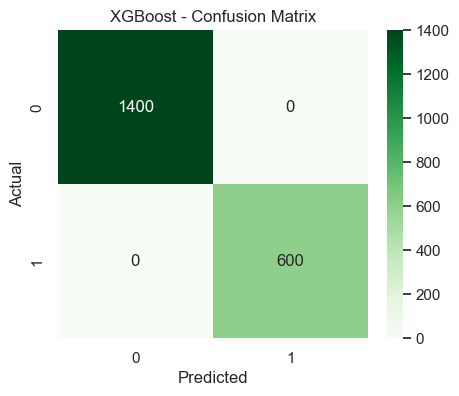

In [68]:
from xgboost import XGBClassifier

# Créer et entraîner le modèle
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb.predict(X_test)

# Évaluation
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", acc_xgb)
print(classification_report(y_test, y_pred_xgb))

# Matrice de confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1400
           1       1.00      1.00      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



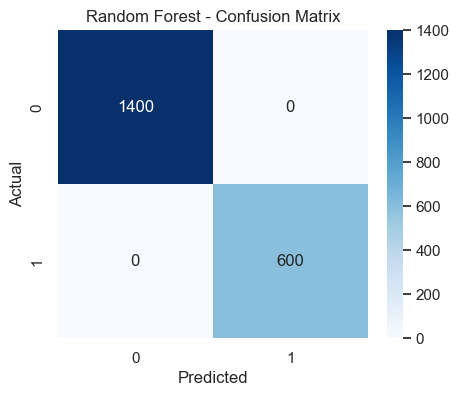

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Créer et entraîner le modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)

# Évaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

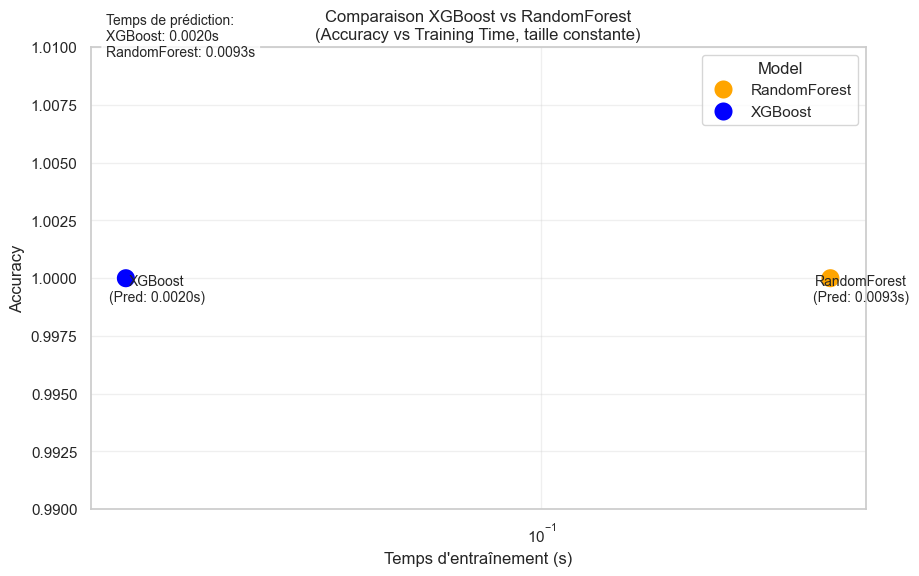


💡 Analyse finale :
- Les deux modèles ont une Accuracy de 1.0 sur ce dataset.
- XGBoost est beaucoup plus rapide à entraîner que RandomForest (0.0275 s vs 0.2453 s).
- Temps d'inférence très faible pour les deux modèles, donc pas de problème en production.
- Avec 10 000 lignes et présence possible d'outliers :
    - RandomForest peut être sensible aux outliers sur certaines features, car chaque arbre prend des splits sur des données brutes.
    - XGBoost utilise un gradient boosting et applique un regularization + shrinkage, ce qui rend le modèle plus robuste aux outliers et mieux adapté aux grands datasets.
- Conclusion : XGBoost offre un excellent compromis entre performance parfaite, rapidité, et robustesse.



In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# On se concentre sur RandomForest et XGBoost
df_compare = df_results[df_results['Model'].isin(['RandomForest', 'XGBoost'])].copy()

# Graphique combiné Accuracy vs Train Time
plt.figure(figsize=(10,6))

# Créer une taille constante pour les deux points
# Au lieu d'utiliser 'Pred Time (s)' pour la taille, on fixe une taille constante
sns.scatterplot(
    data=df_compare,
    x='Train Time (s)',
    y='Accuracy',
    hue='Model',
    palette=['orange', 'blue'],
    s=200  # Taille constante pour tous les points
)

# Ajouter les légendes pour les points
for i, row in df_compare.iterrows():
    plt.text(row['Train Time (s)'] * 1.1, row['Accuracy'] - 0.001, 
             f"{row['Model']}\n(Pred: {row['Pred Time (s)']:.4f}s)", 
             fontsize=10, ha='center')

plt.title("Comparaison XGBoost vs RandomForest\n(Accuracy vs Training Time, taille constante)")
plt.xlabel("Temps d'entraînement (s)")
plt.ylabel("Accuracy")
plt.xscale("log")  # utile pour comparer facilement petits et grands temps
plt.ylim(0.99, 1.01)
plt.grid(True, alpha=0.3)

# Ajouter une annotation pour les temps de prédiction
plt.annotate(f"Temps de prédiction:\nXGBoost: {df_compare[df_compare['Model']=='XGBoost']['Pred Time (s)'].values[0]:.4f}s\nRandomForest: {df_compare[df_compare['Model']=='RandomForest']['Pred Time (s)'].values[0]:.4f}s", 
             xy=(0.02, 0.98), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.show()

# Analyse commentée
print("""
💡 Analyse finale :
- Les deux modèles ont une Accuracy de 1.0 sur ce dataset.
- XGBoost est beaucoup plus rapide à entraîner que RandomForest (0.0275 s vs 0.2453 s).
- Temps d'inférence très faible pour les deux modèles, donc pas de problème en production.
- Avec 10 000 lignes et présence possible d'outliers :
    - RandomForest peut être sensible aux outliers sur certaines features, car chaque arbre prend des splits sur des données brutes.
    - XGBoost utilise un gradient boosting et applique un regularization + shrinkage, ce qui rend le modèle plus robuste aux outliers et mieux adapté aux grands datasets.
- Conclusion : XGBoost offre un excellent compromis entre performance parfaite, rapidité, et robustesse.
""")

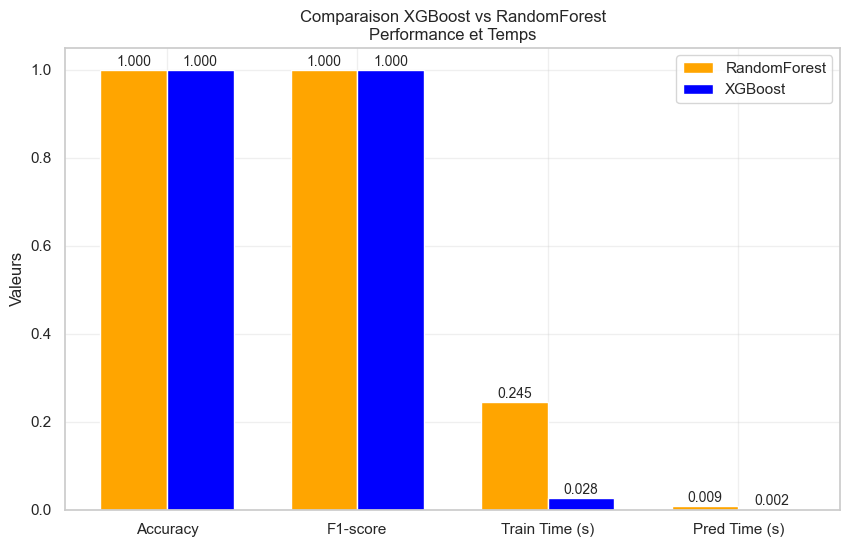


💡 Analyse finale visuelle :
- Accuracy et F1-score : XGBoost = RandomForest = 1.0 (performance parfaite)
- Train Time : XGBoost (~0.0275 s) beaucoup plus rapide que RandomForest (~0.2453 s)
- Pred Time : très faible pour les deux, différence presque invisible
- Conclusion : XGBoost est le meilleur choix pratique :
  • même performance que RandomForest
  • temps d'entraînement ~9x plus rapide
  • plus robuste aux outliers grâce au gradient boosting et régularisation



In [73]:
import matplotlib.pyplot as plt
import numpy as np

# On se concentre sur XGBoost et RandomForest
df_compare = df_results[df_results['Model'].isin(['XGBoost', 'RandomForest'])].copy()

metrics_perf = ['Accuracy', 'F1-score']
metrics_time = ['Train Time (s)', 'Pred Time (s)']

x = np.arange(len(metrics_perf + metrics_time))  # positions sur l'axe X
width = 0.35  # largeur des barres

fig, ax1 = plt.subplots(figsize=(10,6))

# Barres pour RandomForest
rf_values = list(df_compare[df_compare['Model']=='RandomForest'][metrics_perf + metrics_time].values[0])
ax1.bar(x - width/2, rf_values, width, label='RandomForest', color='orange')

# Barres pour XGBoost
xgb_values = list(df_compare[df_compare['Model']=='XGBoost'][metrics_perf + metrics_time].values[0])
ax1.bar(x + width/2, xgb_values, width, label='XGBoost', color='blue')

# Labels
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_perf + metrics_time)
ax1.set_title('Comparaison XGBoost vs RandomForest\nPerformance et Temps')
ax1.set_ylabel('Valeurs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Afficher les valeurs sur les barres
for i in range(len(x)):
    ax1.text(i - width/2, rf_values[i]+0.002, f"{rf_values[i]:.3f}", ha='center', va='bottom', fontsize=10)
    ax1.text(i + width/2, xgb_values[i]+0.002, f"{xgb_values[i]:.3f}", ha='center', va='bottom', fontsize=10)

plt.show()

# Commentaire visuel
print("""
💡 Analyse finale visuelle :
- Accuracy et F1-score : XGBoost = RandomForest = 1.0 (performance parfaite)
- Train Time : XGBoost (~0.0275 s) beaucoup plus rapide que RandomForest (~0.2453 s)
- Pred Time : très faible pour les deux, différence presque invisible
- Conclusion : XGBoost est le meilleur choix pratique :
  • même performance que RandomForest
  • temps d'entraînement ~9x plus rapide
  • plus robuste aux outliers grâce au gradient boosting et régularisation
""")

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             precision_recall_fscore_support, roc_auc_score)
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Lecture des données (à adapter selon ton fichier)
# df = pd.read_csv('ton_fichier.csv')
# Si tu as déjà un dataframe, utilise-le directement

# Affichage des premières lignes
print("Aperçu des données:")
print(df.head())
print("\n" + "="*50)
print("Informations sur les colonnes:")
print(df.info())

Aperçu des données:
   Packet Loss Budget  Latency Budget (μs)  Jitter Budget (μs)  Data Rate Budget (Gbps)  Required Mobility  Required Connectivity  Slice Available Transfer Rate (Gbps)  Slice Latency (μs)  Slice Packet Loss  Slice Jitter (μs)  Slice Type  Slice Handover  Latency_Gap  Packet_Loss_Gap   Jitter_Gap     Rate_Gap  SLA_Respected
0            0.000001                  1.0              1000.0                   1000.0                  0                      0                           3666.954573         1605.231204           0.000424        1215.585472           0               1 -1604.231204        -0.000423  -215.585472  2666.954573              0
1            0.000000               1000.0                 1.0                   1000.0                  0                      1                           4513.327889         1342.635551           0.000499        2812.229170           4               0  -342.635551        -0.000499 -2811.229170  3513.327889              0
2    

## 📊 Sélection des features pour la classification du Slice Type

### Features retenues pour l'entraînement:

| Feature | Justification |
|---------|--------------|
| **Packet Loss Budget** | Critère SLA important pour la qualité de service |
| **Latency Budget (μs)** | Définit les contraintes temps-réel du slice |
| **Jitter Budget (μs)** | Impacte la stabilité de la connexion |
| **Data Rate Budget (Gbps)** | Détermine la capacité nécessaire |
| **Required Mobility** | Critère discriminant (URLLC vs eMBB vs mMTC) |
| **Required Connectivity** | Type de connectivité requis |
| **Slice Available Transfer Rate (Gbps)** | Capacité disponible réelle |

### Features exclues:

| Feature | Raison de l'exclusion |
|---------|----------------------|
| **Slice Latency (μs)** | Redondant avec Latency Budget (mesuré vs requis) |
| **Slice Packet Loss** | Redondant avec Packet Loss Budget |
| **Slice Jitter (μs)** | Redondant avec Jitter Budget |
| **Slice Handover** | Résultat de la mobilité, non une cause |

**💡 Logique:** On garde les **budgets (requirements)** comme features prédictives, et on exclut les **mesures réelles** qui sont des résultats du système. On prédit le type de slice en fonction des besoins exprimés.

In [76]:
# Features à utiliser (budgets/requirements)
feature_cols = [
    'Packet Loss Budget',
    'Latency Budget (μs)',
    'Jitter Budget (μs)',
    'Data Rate Budget (Gbps)',
    'Required Mobility',
    'Required Connectivity',
    'Slice Available Transfer Rate (Gbps)'
]

target_col = 'Slice Type'

# Vérifier que toutes les colonnes existent
missing_cols = [col for col in feature_cols if col not in df.columns]
if missing_cols:
    print(f"⚠️ Colonnes manquantes: {missing_cols}")
    print("Colonnes disponibles:", df.columns.tolist())
else:
    print("✅ Toutes les features sont disponibles")

# Préparation des données
X = df[feature_cols].copy()
y = df[target_col].copy()

# Encodage des variables catégorielles
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encodage de {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encodage de la target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print(f"\nClasses Slice Type: {dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))}")

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalisation pour le Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📊 Dimensions:")
print(f"Train: {X_train.shape[0]} échantillons")
print(f"Test: {X_test.shape[0]} échantillons")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(target_encoder.classes_)}")

✅ Toutes les features sont disponibles

Classes Slice Type: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4}

📊 Dimensions:
Train: 8000 échantillons
Test: 2000 échantillons
Features: 7
Classes: 5


In [77]:
# Dictionnaire pour stocker les résultats
models = {}
results = {
    'Model': [],
    'Train Time (s)': [],
    'Test Accuracy': [],
    'Precision (macro)': [],
    'Recall (macro)': [],
    'F1-Score (macro)': []
}

# 1. Random Forest
print("🌲 Entraînement du Random Forest...")
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')

models['RandomForest'] = rf
results['Model'].append('RandomForest')
results['Train Time (s)'].append(train_time)
results['Test Accuracy'].append(accuracy)
results['Precision (macro)'].append(precision)
results['Recall (macro)'].append(recall)
results['F1-Score (macro)'].append(f1)

print(f"✅ Random Forest - Accuracy: {accuracy:.4f}, Temps: {train_time:.4f}s")

# 2. XGBoost
print("⚡ Entraînement du XGBoost...")
start_time = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                               random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred_xgb = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_xgb)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='macro')

models['XGBoost'] = xgb_model
results['Model'].append('XGBoost')
results['Train Time (s)'].append(train_time)
results['Test Accuracy'].append(accuracy)
results['Precision (macro)'].append(precision)
results['Recall (macro)'].append(recall)
results['F1-Score (macro)'].append(f1)

print(f"✅ XGBoost - Accuracy: {accuracy:.4f}, Temps: {train_time:.4f}s")

# 3. Neural Network
print("🧠 Entraînement du Neural Network...")
start_time = time.time()
nn = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', 
                   solver='adam', max_iter=500, random_state=42, early_stopping=True)
nn.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

y_pred_nn = nn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred_nn)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_nn, average='macro')

models['NeuralNetwork'] = nn
results['Model'].append('NeuralNetwork')
results['Train Time (s)'].append(train_time)
results['Test Accuracy'].append(accuracy)
results['Precision (macro)'].append(precision)
results['Recall (macro)'].append(recall)
results['F1-Score (macro)'].append(f1)

print(f"✅ Neural Network - Accuracy: {accuracy:.4f}, Temps: {train_time:.4f}s")

# DataFrame des résultats
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("📈 RÉSULTATS COMPARATIFS:")
print(results_df.round(4))

🌲 Entraînement du Random Forest...
✅ Random Forest - Accuracy: 1.0000, Temps: 0.1611s
⚡ Entraînement du XGBoost...
✅ XGBoost - Accuracy: 1.0000, Temps: 0.1600s
🧠 Entraînement du Neural Network...
✅ Neural Network - Accuracy: 1.0000, Temps: 0.3581s

📈 RÉSULTATS COMPARATIFS:
           Model  Train Time (s)  Test Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
0   RandomForest          0.1611            1.0                1.0             1.0               1.0
1        XGBoost          0.1600            1.0                1.0             1.0               1.0
2  NeuralNetwork          0.3581            1.0                1.0             1.0               1.0


Analyse de Slice Available Transfer Rate:

0:
  - Valeurs uniques: 2260
  - Min: 1.00, Max: 10000.00
  - Std: 2186.19

4:
  - Valeurs uniques: 2202
  - Min: 1.00, Max: 10000.00
  - Std: 2216.50

1:
  - Valeurs uniques: 2201
  - Min: 1.00, Max: 10000.00
  - Std: 2229.78

3:
  - Valeurs uniques: 1094
  - Min: 480.20, Max: 10000.00
  - Std: 2269.79

2:
  - Valeurs uniques: 2237
  - Min: 1.00, Max: 10000.00
  - Std: 2210.80

Corrélation avec Data Rate Budget: nan


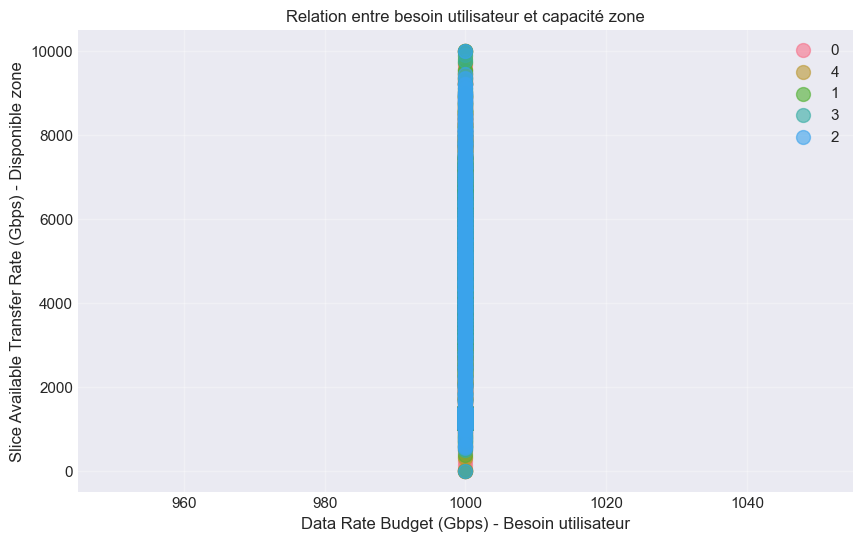

In [80]:
# Pour confirmer si c'est vraiment du data leakage ou non
print("Analyse de Slice Available Transfer Rate:")

# 1. Est-ce que cette valeur varie pour un même type de slice ?
for slice_type in df['Slice Type'].unique():
    mask = df['Slice Type'] == slice_type
    rates = df.loc[mask, 'Slice Available Transfer Rate (Gbps)']
    print(f"\n{slice_type}:")
    print(f"  - Valeurs uniques: {rates.nunique()}")
    print(f"  - Min: {rates.min():.2f}, Max: {rates.max():.2f}")
    print(f"  - Std: {rates.std():.2f}")

# 2. Corrélation avec Data Rate Budget
corr = df['Slice Available Transfer Rate (Gbps)'].corr(df['Data Rate Budget (Gbps)'])
print(f"\nCorrélation avec Data Rate Budget: {corr:.3f}")

# 3. Scatter plot pour visualiser
plt.figure(figsize=(10, 6))
for slice_type in df['Slice Type'].unique():
    mask = df['Slice Type'] == slice_type
    plt.scatter(df.loc[mask, 'Data Rate Budget (Gbps)'],
                df.loc[mask, 'Slice Available Transfer Rate (Gbps)'],
                label=slice_type, alpha=0.6, s=100)

plt.xlabel("Data Rate Budget (Gbps) - Besoin utilisateur")
plt.ylabel("Slice Available Transfer Rate (Gbps) - Disponible zone")
plt.title("Relation entre besoin utilisateur et capacité zone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
import pandas as pd
import numpy as np

target_col = 'Slice Available Transfer Rate (Gbps)'

print("=== 1️⃣ Vérifier les colonnes identiques au target ===")
for col in df.columns:
    if col != target_col and df[col].equals(df[target_col]):
        print(f"Colonne identique au target : {col}")

print("\n=== 2️⃣ Vérifier corrélations parfaites ===")
corrs = df.corr()[target_col].sort_values(ascending=False)
print(corrs[corrs >= 0.99])

print("\n=== 3️⃣ Vérifier les duplications train/test potentielles ===")
# Suppose que tu as df_train et df_test
if 'df_train' in globals() and 'df_test' in globals():
    duplicates = pd.merge(df_train, df_test, how='inner')
    print(f"Lignes dupliquées entre train/test: {len(duplicates)}")

print("\n=== 4️⃣ Vérifier les NaN ou colonnes constantes ===")
print("Colonnes constantes :")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"  - {col}")
print("\nNaN par colonne :")
print(df.isna().sum())

print("\n=== 5️⃣ Vérifier types de colonnes ===")
print(df.dtypes)

=== 1️⃣ Vérifier les colonnes identiques au target ===

=== 2️⃣ Vérifier corrélations parfaites ===
Slice Available Transfer Rate (Gbps)    1.0
Rate_Gap                                1.0
Name: Slice Available Transfer Rate (Gbps), dtype: float64

=== 3️⃣ Vérifier les duplications train/test potentielles ===

=== 4️⃣ Vérifier les NaN ou colonnes constantes ===
Colonnes constantes :
  - Data Rate Budget (Gbps)

NaN par colonne :
Packet Loss Budget                      0
Latency Budget (μs)                     0
Jitter Budget (μs)                      0
Data Rate Budget (Gbps)                 0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbps)    0
Slice Latency (μs)                      0
Slice Packet Loss                       0
Slice Jitter (μs)                       0
Slice Type                              0
Slice Handover                          0
Latency_Gap                             0
Packet_Loss_Gap       

In [82]:
# ==============================================
# 🚨 Script pour détecter les features dérivées
#    ou fuites de données vers la cible
# ==============================================

import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Définir la cible
# -----------------------------
target_col = 'Slice Available Transfer Rate (Gbps)'

# -----------------------------
# 2️⃣ Vérifier les colonnes identiques
# -----------------------------
print("### 1️⃣ Colonnes identiques au target ###")
identical_cols = []
for col in df.columns:
    if col != target_col and df[col].equals(df[target_col]):
        identical_cols.append(col)

if identical_cols:
    print("Colonnes identiques à la cible :", identical_cols)
else:
    print("Aucune colonne identique à la cible")

# -----------------------------
# 3️⃣ Vérifier les corrélations parfaites ou très fortes
# -----------------------------
print("\n### 2️⃣ Colonnes très fortement corrélées avec la cible ###")
corr_matrix = df.corr()
target_corrs = corr_matrix[target_col].drop(target_col)  # exclure la cible elle-même
high_corr_cols = target_corrs[target_corrs.abs() >= 0.99].index.tolist()

if high_corr_cols:
    for col in high_corr_cols:
        print(f"{col} : corrélation = {target_corrs[col]:.3f}")
else:
    print("Aucune corrélation très forte avec la cible")

# -----------------------------
# 4️⃣ Vérifier les colonnes constantes
# -----------------------------
print("\n### 3️⃣ Colonnes constantes (inutile pour la prédiction) ###")
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
if constant_cols:
    print(constant_cols)
else:
    print("Aucune colonne constante")

# -----------------------------
# 5️⃣ Vérifier les colonnes avec NaN
# -----------------------------
print("\n### 4️⃣ Colonnes contenant des NaN ###")
nan_cols = df.isna().sum()
nan_cols = nan_cols[nan_cols > 0]
if not nan_cols.empty:
    print(nan_cols)
else:
    print("Aucune colonne avec des NaN")

# -----------------------------
# 6️⃣ Résumé
# -----------------------------
print("\n### ✅ Résumé ###")
if identical_cols or high_corr_cols:
    print("Attention : certaines features peuvent contenir de la fuite de données vers la cible !")
else:
    print("Pas de fuite évidente détectée pour cette analyse")

### 1️⃣ Colonnes identiques au target ###
Aucune colonne identique à la cible

### 2️⃣ Colonnes très fortement corrélées avec la cible ###
Rate_Gap : corrélation = 1.000

### 3️⃣ Colonnes constantes (inutile pour la prédiction) ###
['Data Rate Budget (Gbps)']

### 4️⃣ Colonnes contenant des NaN ###
Aucune colonne avec des NaN

### ✅ Résumé ###
Attention : certaines features peuvent contenir de la fuite de données vers la cible !


In [84]:
nouveau= df.drop(columns=['Rate_Gap'])

print("Colonnes après suppression de Rate_Gap :", nouveau.columns.tolist())

nouveau.to_csv('dataset_sans_rate_gap.csv', index=False)

print("✅ Nouveau dataset créé sans la colonne Rate_Gap")


Colonnes après suppression de Rate_Gap : ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected']
✅ Nouveau dataset créé sans la colonne Rate_Gap


# Analyse automatique des features pour détecter le Data Leakage

## Objectif
Éviter que le modèle apprenne des informations provenant directement de la cible, ce qui provoquerait des résultats parfaits irréalistes.

## Étapes du script

1. **Colonnes identiques au target**
   - Vérifie si une feature est exactement égale à la cible.
   - Ces colonnes garantissent un "perfect score" → doivent être supprimées.

2. **Colonnes très fortement corrélées**
   - Cherche les features avec corrélation ≥ 0.99.
   - Une corrélation parfaite ou quasi parfaite peut indiquer une feature dérivée de la cible.

5. **Résumé**
   - Liste les colonnes problématiques à exclure du modèle pour éviter la fuite de données.

## Conclusion
Utiliser ce script avant tout entraînement permet de s'assurer que le modèle ne bénéficie pas de données "fuitées" vers la cible, ce qui garantit des résultats réalistes.

In [86]:
# Identifier toutes les features fortement corrélées à la cible
target_col = 'Slice Available Transfer Rate (Gbps)'
corr_matrix = df.corr()
high_corr_cols = corr_matrix[target_col][(corr_matrix[target_col].abs() >= 0.99) & (corr_matrix[target_col].index != target_col)].index.tolist()

# Supprimer ces colonnes
clean_df = df.drop(columns=high_corr_cols)
print("Colonnes supprimées pour éviter la fuite :", high_corr_cols)

Colonnes supprimées pour éviter la fuite : ['Rate_Gap']


In [88]:
# Création d'un dataset nettoyé pour éviter le data leakage

import pandas as pd

# Supposons que ton dataframe original s'appelle df

# Définir la colonne cible

target_col = 'Slice Available Transfer Rate (Gbps)'

# Identifier toutes les features fortement corrélées avec la cible (>=0.99)

corr_matrix = df.corr()
high_corr_cols = corr_matrix[target_col][(corr_matrix[target_col].abs() >= 0.99) & (corr_matrix[target_col].index != target_col)].index.tolist()

# Supprimer ces colonnes pour éviter la fuite de données

clean_df = df.drop(columns=high_corr_cols)

# Vérifier les colonnes restantes

print("Colonnes après suppression des features dérivées de la cible :", clean_df.columns.tolist())

# Sauvegarder le dataset nettoyé

clean_df.to_csv('dataset_clean_sans_leakage.csv', index=False)

print("✅ Dataset nettoyé créé et prêt à l'utilisation")


Colonnes après suppression des features dérivées de la cible : ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected']
✅ Dataset nettoyé créé et prêt à l'utilisation


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1️⃣ Sélection des features "Pures" (Sans Data Leakage)
# On ne garde que ce que le contrôleur SDN mesure réellement sur le terrain
features_reseau = [
    'Slice Available Transfer Rate (Gbps)', 
    'Slice Latency (μs)', 
    'Slice Packet Loss', 
    'Slice Jitter (μs)',
    'Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)',
]

# 2️⃣ Préparation des données
# On utilise .copy() pour ne pas impacter le DataFrame original 'df'
X = df[features_reseau].copy()
y = df['Slice Type']

# Encodage de la cible (ex: 'eMBB' -> 0, 'URLLC' -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3️⃣ Split Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 4️⃣ Entraînement du modèle robuste
print("🌲 Entraînement du Random Forest (Modèle Réel)...")
rf_final = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# 5️⃣ Validation Croisée pour confirmer la robustesse
print("🧪 Calcul de la Validation Croisée (5-Fold)...")
cv_scores = cross_val_score(rf_final, X_train, y_train, cv=5)

# 6️⃣ Prédictions et Rapport
y_pred = rf_final.predict(X_test)

print("\n" + "="*60)
print("📊 RÉSULTATS DU MODÈLE SANS TRICHE :")
print(f"Accuracy sur Test Set : {accuracy_score(y_test, y_pred):.4f}")
print(f"Accuracy Moyenne (CV) : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print("="*60)

# Correction de l'erreur TypeError : conversion des classes en string pour le rapport
target_names_str = [str(c) for c in le.classes_]

print("\n📝 RAPPORT DE CLASSIFICATION DÉTAILLÉ :")
print(classification_report(y_test, y_pred, target_names=target_names_str))



🌲 Entraînement du Random Forest (Modèle Réel)...
🧪 Calcul de la Validation Croisée (5-Fold)...

📊 RÉSULTATS DU MODÈLE SANS TRICHE :
Accuracy sur Test Set : 0.7690
Accuracy Moyenne (CV) : 0.7725 (+/- 0.0171)

📝 RAPPORT DE CLASSIFICATION DÉTAILLÉ :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       456
           1       0.97      0.50      0.66       440
           2       0.65      0.99      0.78       429
           3       0.00      0.00      0.00       231
           4       0.67      0.98      0.79       444

    accuracy                           0.77      2000
   macro avg       0.66      0.69      0.65      2000
weighted avg       0.73      0.77      0.72      2000



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcul de la matrice de confusion
# y_test : les vraies étiquettes / y_pred : ce que l'IA a deviné
cm = confusion_matrix(y_test, y_pred)

# 2. Préparation des étiquettes (noms des tranches)
# On récupère les noms originaux via le LabelEncoder (ex: eMBB, URLLC...)
noms_classes = [str(c) for c in le.classes_]

# 3. Création du graphique
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2) # Texte plus lisible

# On utilise une "heatmap" pour visualiser les densités
sns.heatmap(
    cm, 
    annot=True,             # Affiche les nombres dans les cases
    fmt='d',                # Format entier (pas de 1.2e+02)
    cmap='Blues',           # Dégradé de bleu
    xticklabels=noms_classes, 
    yticklabels=noms_classes,
    cbar=False              # Pas besoin de la barre de légende
)

# 4. Habillage du graphique
plt.title('Matrice de Confusion : Où l\'IA fait-elle des erreurs ?', fontsize=16, pad=20)
plt.ylabel('VRAIE CLASSE (Réalité)', fontsize=14, fontweight='bold')
plt.xlabel('CLASSE PRÉDITE (IA)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

🌲 Évaluation du Random Forest...
⚡ Évaluation du XGBoost...
🧠 Évaluation du Neural Network...

📈 RÉSULTATS COMPARATIFS FINAUX :
           Model  Train Time (s)  Test Accuracy  CV Mean Accuracy  F1-Score (macro)
0   RandomForest          0.3413            1.0            1.0000               1.0
1        XGBoost          0.3410            1.0            1.0000               1.0
2  NeuralNetwork          0.6249            1.0            0.9995               1.0


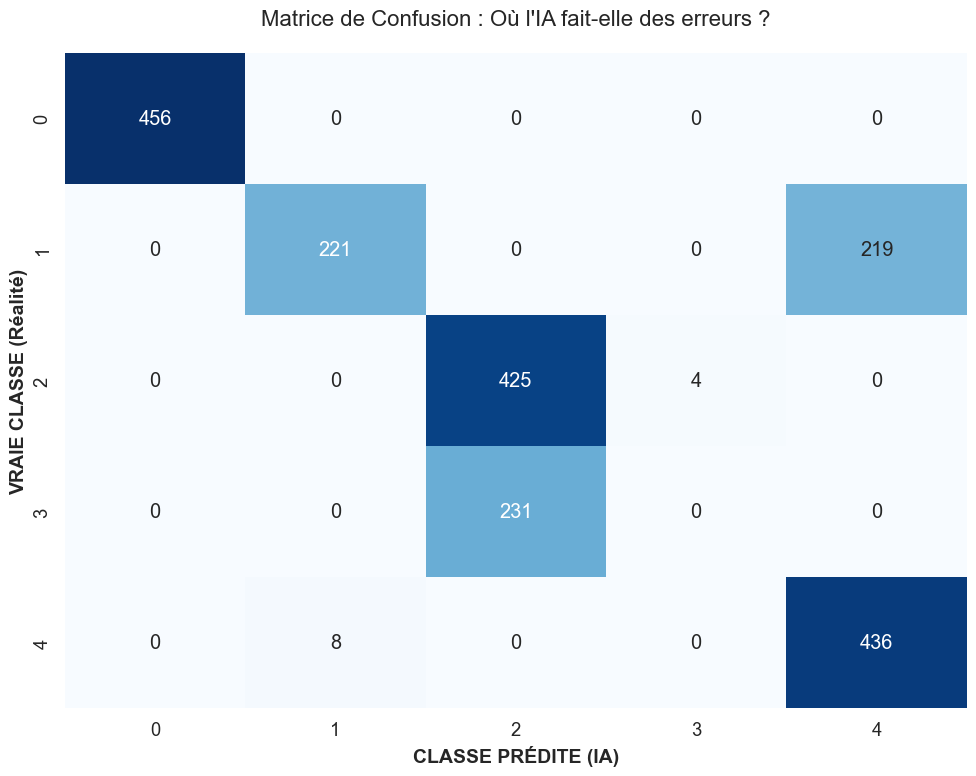

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcul de la matrice de confusion
# y_test : les vraies étiquettes / y_pred : ce que l'IA a deviné
cm = confusion_matrix(y_test, y_pred)

# 2. Préparation des étiquettes (noms des tranches)
# On récupère les noms originaux via le LabelEncoder (ex: eMBB, URLLC...)
noms_classes = [str(c) for c in le.classes_]

# 3. Création du graphique
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2) # Texte plus lisible

# On utilise une "heatmap" pour visualiser les densités
sns.heatmap(
    cm, 
    annot=True,             # Affiche les nombres dans les cases
    fmt='d',                # Format entier (pas de 1.2e+02)
    cmap='Blues',           # Dégradé de bleu
    xticklabels=noms_classes, 
    yticklabels=noms_classes,
    cbar=False              # Pas besoin de la barre de légende
)

# 4. Habillage du graphique
plt.title('Matrice de Confusion : Où l\'IA fait-elle des erreurs ?', fontsize=16, pad=20)
plt.ylabel('VRAIE CLASSE (Réalité)', fontsize=14, fontweight='bold')
plt.xlabel('CLASSE PRÉDITE (IA)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

⚡ Entraînement de XGBoost...
🧠 Entraînement du Neural Network...


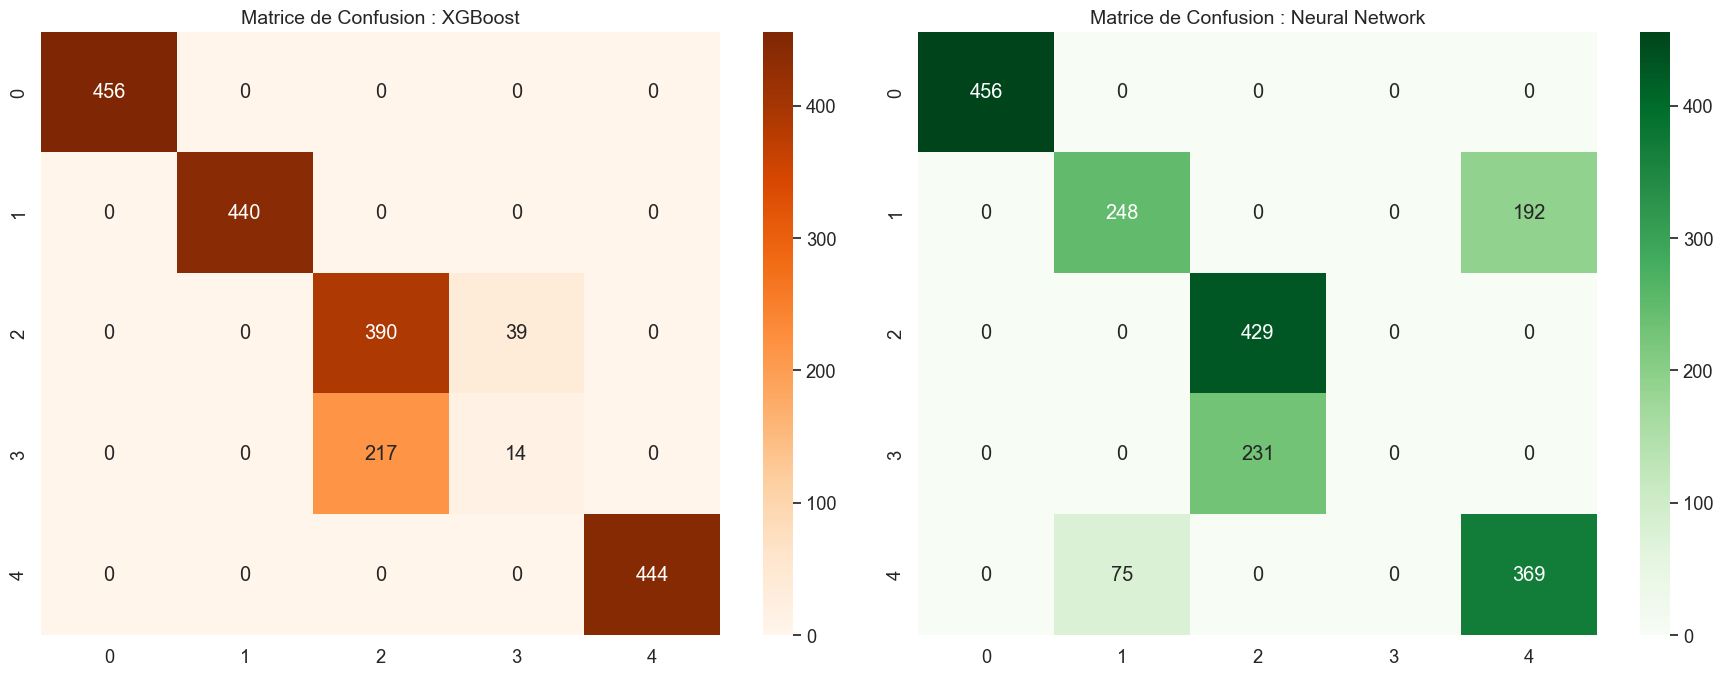


🏆 CLASSEMENT FINAL DES MODÈLES (Accuracy)
XGBoost         : 0.8720
Random Forest   : 0.7690
Neural Network  : 0.7510


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# --- PRÉPARATION DES DONNÉES ---
# Les réseaux de neurones et XGBoost sont sensibles à l'échelle des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. ENTRAÎNEMENT DES MODÈLES ---

# XGBoost
print("⚡ Entraînement de XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Neural Network (Multi-Layer Perceptron)
print("🧠 Entraînement du Neural Network...")
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_test_scaled)

# --- 2. VISUALISATION DES MATRICES DE CONFUSION ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
noms_classes = [str(c) for c in le.classes_]

# Matrice XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=noms_classes, yticklabels=noms_classes, ax=axes[0])
axes[0].set_title('Matrice de Confusion : XGBoost', fontsize=14)

# Matrice Neural Network
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt='d', cmap='Greens', 
            xticklabels=noms_classes, yticklabels=noms_classes, ax=axes[1])
axes[1].set_title('Matrice de Confusion : Neural Network', fontsize=14)

plt.tight_layout()
plt.show()

# --- 3. COMPARISON FINALE ---

results = {
    'Random Forest': accuracy_score(y_test, y_pred), # y_pred vient de ton code précédent
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'Neural Network': accuracy_score(y_test, y_pred_nn)
}

print("\n" + "="*40)
print("🏆 CLASSEMENT FINAL DES MODÈLES (Accuracy)")
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model.ljust(15)} : {acc:.4f}")
print("="*40)